In [96]:
import sys
import time
import pathlib
cur_path = pathlib.Path().resolve().parent.absolute()
src_loc = cur_path.joinpath("src")
util_loc = src_loc.joinpath("utils")
sys.path.append(str(cur_path))
sys.path.append(str(src_loc))
sys.path.append(str(util_loc))

# 1 Load Data

### 1.1 Setup env and load packages

In [97]:
# load the libraries and initial settings
import os
import pathlib
import time
import datetime
import subprocess
import pyarrow as pa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from src.conf import Conf
from src.utils.utils import elapsed_time, save_data, load_data
from src.utils.sql import sql
# Load configuration
confparam_path = cur_path.joinpath("src", "conf", "conf_dev.yml")
dataparam_path = cur_path.joinpath("src", "data", "ctp_dbt_model", "dbt_project.yml")
conf = Conf(confparam_path, dataparam_path )
project_start_time = time.time()

### 1.2 query data from EDH

#### 1.2.1 Query node features

In [98]:
# query for customer relationship


cust_query="""
SELECT *
FROM dl_analytics.ctp_cust_connection_dbt1
"""

# query for doctor&lawyer relationship

doc_lawyer_query="""
SELECT *
FROM dl_analytics.ctp_doctor_lawyer_pair_dbt1
"""

# query for docotr&psych relationship

doc_psych_query="""
SELECT *
FROM dl_analytics.ctp_doctor_psych_pair_dbt1
"""

# query for doctor&repairer relationship

doc_repair_query="""
SELECT *
FROM dl_analytics.ctp_doctor_repairer_pair_dbt1
"""

# # query for payment relationship

# payment_query="""
# SELECT *
# FROM dl_analytics.ctp_payment_connection_dbt
# """

# query for vehicle relationship

vehicle_query="""
SELECT *
FROM dl_analytics.ctp_vehicle_connection_dbt1
"""

In [99]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
cust_df = sql(conf=conf, fn="get", sql=cust_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.913
Total elapsed time: 0:0:00.956


In [100]:
# Check for duplicates based on all columns
print('*'*60)
print("check duplicates")
duplicates = cust_df[cust_df.duplicated()]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(cust_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 13658
Number of duplicates is 0


In [101]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_lawyer_df = sql( conf=conf, fn="get", sql=doc_lawyer_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:05.118
Total elapsed time: 0:0:06.122


In [102]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_psych_df = sql(conf=conf, fn="get", sql=doc_psych_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.948
Total elapsed time: 0:0:08.091


In [103]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_repair_df = sql(conf=conf, fn="get", sql=doc_repair_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:02.186
Total elapsed time: 0:0:10.305


In [104]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
vehicle_df = sql(conf=conf, fn="get", sql=vehicle_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:08.882
Total elapsed time: 0:0:19.213


#### 1.2.2 Query node features

In [105]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
node_query='SELECT * FROM dl_analytics.ctp_node_features_dbt'
node_df = sql(conf=conf, fn="get", sql=node_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:10.917
Total elapsed time: 0:0:30.147


In [106]:
node_df

,claim_number,policy_number,claim_id,claim_lodgement_date,claim_loss_date,claim_report_date,late_lodgement_days,late_report_days,claim_status_name,claim_how_reported_name,...,max_days_late_recovery_from_loss,avg_days_late_recovery_from_loss,diff_account_same_medical_provider_flag,max_claims_same_provider_amt,max_accounts_same_provider_amt,psych_claim_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult_flag
0,NWRTP1901528,CTP559879231,2238219,2019-06-11,2019-05-28,2019-06-11,14,14,Closed,Phone,...,933.000,933.000,1.000,0.000,0.000,1,1,0,0,0
1,NWRND2400011,NDS*11111111,6543664,2024-01-25,2024-01-15,2024-01-25,10,10,Open,Phone,...,448.000,249.000,1.000,0.000,0.000,0,1,1,0,0
2,NWRTP2002583,CTP330727758,3604755,2020-11-18,2020-10-19,2020-11-18,30,30,Closed,Phone,...,30.000,30.000,1.000,0.000,0.000,1,0,0,0,0
3,NWRTP1903003,CTP226730457,2610424,2019-10-30,2019-08-31,2019-10-30,60,60,Closed,Phone,...,108.000,108.000,1.000,0.000,0.000,1,1,0,0,0
4,NWRTP2500948,CTP687001777,7637055,2025-04-11,2022-10-31,2025-04-11,893,893,Open,Phone,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31867,NWRTP2500281,CTP627665193,7460481,2025-02-06,2025-01-05,2025-02-06,32,32,Open,Phone,...,59.000,59.000,1.000,0.000,0.000,1,0,0,0,0
31868,NWRTP2101629,CTP607597218,4170610,2021-06-25,2021-03-22,2021-06-25,95,95,Closed,Phone,...,119.000,119.000,0.000,0.000,0.000,0,0,0,0,0
31869,NWRTP1902709,CTP583114203,2538202,2019-10-03,2019-06-11,2019-10-03,114,114,Closed,Phone,...,1472.000,1472.000,1.000,0.000,0.000,1,0,0,0,0
31870,NWRTP1903018,CTP594622926,2613499,2019-10-31,2019-01-31,2019-10-31,273,273,Closed,Phone,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0


In [107]:
# Check for duplicates based on claim number
print('*'*60)
print("check duplicates")
duplicates = node_df[node_df.duplicated(subset=['claim_number'])]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(node_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 31872
Number of duplicates is 7138


### 1.3 create pa schema and save parquet

In [108]:
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(cust_df)
# save data 
save_data(cust_df, conf.data_path, 'customer_connection_data1', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_lawyer_df)
# save data 
save_data(doc_lawyer_df, conf.data_path, 'doc_lawyer_connection_data1', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_psych_df)
# save data 
save_data(doc_psych_df, conf.data_path, 'doc_psych_connection_data1', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_repair_df)
# save data 
save_data(doc_repair_df, conf.data_path, 'doc_repair_connection_data1', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(vehicle_df)
# save data 
save_data(vehicle_df, conf.data_path, 'vehicle_connection_data1', data_extension='parquet', schema=new_schema)


Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\customer_connection_data1.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data1.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data1.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data1.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data1.parquet


In [109]:
# save claim node data
new_schema = pa.Schema.from_pandas(node_df)
save_data(node_df, conf.data_path, 'node_feature', data_extension='parquet', schema=new_schema)

Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet


# 2 Data preprocessing

### 2.1 load data locally

In [110]:
import decimal
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder
import torch
from torch_geometric.data import Data
import numpy as np 
import pandas as pd
from torch_geometric.utils import to_networkx, degree
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_undirected
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities
from datetime import date

In [111]:
project_start_time = time.time()

print('*' * 60)
print("load data locally ...")

function_start_time = time.time()
cust_df=load_data(conf.data_path, 'customer_connection_data1',  data_extension='parquet')
doc_lawyer_df=load_data(conf.data_path, 'doc_lawyer_connection_data1',  data_extension='parquet')
doc_psych_df=load_data(conf.data_path, 'doc_psych_connection_data1',  data_extension='parquet')
doc_repair_df=load_data(conf.data_path, 'doc_repair_connection_data1',  data_extension='parquet')
vehicle_df=load_data(conf.data_path, 'vehicle_connection_data1',  data_extension='parquet')
node_df=load_data(conf.data_path, 'node_feature',  data_extension='parquet')

elapsed_time('load data', project_start_time, function_start_time)

************************************************************
load data locally ...
Loading data locally: C:\GitHub\CTP_syndicate_model\data\customer_connection_data1.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data1.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data1.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data1.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data1.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet

Elapsed time (load data): 0:0:00.227
Total elapsed time: 0:0:00.228


In [112]:
df_geo=pd.read_csv('geocoded_address.csv')
df_geo.head(10)

,claim_number,claim_exposure_id,claimant_name,claimant_address,supplier_name,supplier_role_name,supplier_address,claimant_longitude,claimant_latitude,ext_GEO_ID,gnafPID,supplier_longitude,supplier_latitude
0,NWRND1800164,1,Joshua Cox,"37 Menangle STREET, GANMAIN, NSW, 2702, Australia",gerard malouf and partners solicitors,Legal,"PO BOX 463 , PARRAMATTA, NSW, 2124, AU",147.037,-34.797,AGANSW704808475,GANSW704808475,151.007,-33.814
1,NWRND1900051,2,NASSOUH EL DEBAL,"31 SACKVILLE ST, FAIRFIELD, NSW, 2165, Australia",fit by physio pty ltd,Service Provider,"Shop 2, 363 Beamish Street , CAMPSIE, NSW, 219...",150.949,-33.866,AGANSW716741848,GANSW716741848,151.104,-33.915
2,NWRND1900055,1,Mildred Villapando,"75 Kleins Rd, NORTHMEAD, NSW, 2152, Australia",exphys rehab pty ltd,Service Provider,"PO Box 2154 , Woolooware, NSW, 2230, AU",150.993,-33.790,AGANSW705571192,GANSW705571192,151.141,-34.043
3,NWRND1900118,1,Nicole Shorrock,"2 Inkerman Rd, EMU HEIGHTS, NSW, 2750, Australia",rosalind dayman,Service Provider,"Genesis, Ste 35 76 Rawson St , EPPING, NSW, 21...",150.647,-33.734,AGANSW704686594,GANSW704686594,151.081,-33.772
4,NWRND1900171,1,Darren Hunt,"21 Hereford St, HOBARTVILLE, NSW, 2753, Australia",penrith physiotherapy sports centre,Service Provider,Nepean Private Specialist Centre 1A Barber Ave...,150.745,-33.601,AGANSW704965734,GANSW704965734,150.714,-33.758
5,NWRND2000004,1,SUSAN HOWE,"1-5 PEEL ST, TOUKLEY, NSW, 2263, Australia",interpsych,Service Provider,"Po Box 3125 , ASQUITH, NSW, 2077, AU",151.539,-33.263,AGANSW717749058,GANSW717749058,151.116,-33.687
6,NWRND2000033,1,Jake Bevan,"40 Promenade Av, BATEAU BAY, NSW, 2261, Australia",dws cleaning services pty ltd,Service Provider,"3 Lake Street , LONG JETTY, NSW, 2261, AU",151.466,-33.381,AGANSW704027218,GANSW704027218,151.479,-33.363
7,NWRND2000079,1,Alan Abdo,"110 Sir John Jamison Cct, GLENMORE PARK, NSW, ...",independent living specialists,Service Provider,"PO Box 889 , LANE COVE, NSW, 2066, AU",150.658,-33.788,AGANSW704814019,GANSW704814019,151.167,-33.818
8,NWRND2100001,1,Challie Takis,"34 Elliott Rd, BANYO, QLD, 4014, Australia",dr andrew ryan,Service Provider,"Holy Spirit Northside Hospital 627 Rode Road ,...",153.069,-27.373,AGAQLD154997610,GAQLD154997610,153.023,-27.389
9,NWRND2100001,1,Challie Takis,"34 Elliott Rd, BANYO, QLD, 4014, Australia",dr colin crowe,Service Provider,"Narcosia Anaesthesia Group PO Box 239 , SPRING...",153.069,-27.373,AGAQLD154997610,GAQLD154997610,153.024,-27.459


### Calculate distance

In [113]:
# Earth's radius in kilometers (you can change this to miles if needed)
R = 6371.0

# Convert the longitude and latitude from degrees to radians.
# Ensure the columns are numeric (using .astype(float) if needed).
claimant_lon_rad = np.radians(df_geo['claimant_longitude'].astype(float))
claimant_lat_rad = np.radians(df_geo['claimant_latitude'].astype(float))
supplier_lon_rad = np.radians(df_geo['supplier_longitude'].astype(float))
supplier_lat_rad = np.radians(df_geo['supplier_latitude'].astype(float))

# Calculate the differences between supplier and claimant coordinates.
dlat = supplier_lat_rad - claimant_lat_rad
dlon = supplier_lon_rad - claimant_lon_rad

# Compute the Haversine formula.
a = np.sin(dlat / 2) ** 2 + np.cos(claimant_lat_rad) * np.cos(supplier_lat_rad) * np.sin(dlon / 2) ** 2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Calculate the distance.
df_geo["max_claimant_supplier_distance"] = R * c

In [114]:
df_distance = df_geo.groupby('claim_number', as_index=False)["max_claimant_supplier_distance"].max()
df_distance

,claim_number,max_claimant_supplier_distance
0,NWRND1800030,740.966
1,NWRND1800058,732.542
2,NWRND1800109,253.793
3,NWRND1800121,107.711
4,NWRND1800140,226.336
...,...,...
5909,NWRTP2500147,0.884
5910,NWRTP2500161,19.333
5911,NWRTP2500165,1.548
5912,NWRTP2500178,720.865


In [115]:
# merged_df = pd.merge(node_df, df_distance, on='claim_number', how='left')
# merged_df

### 2.2 Node features engineering 

In [116]:
# input_dataframe=merged_df.copy()
input_dataframe=node_df.copy()

In [117]:
def data_transformation(input_dataframe):
        """
        Function to perform data preparation steps on the given model_data DataFrame.

        Args:
        - input_dataframe: DataFrame containing the data to be prepared

        Returns:
        - model_data: DataFrame with the prepared data including node features
        """

        # Remove duplicates from input dataframe
        input_dataframe = input_dataframe.drop_duplicates(subset=['claim_number'], keep='first')

        # Convert datatype to get over Decimal
        for x in list(input_dataframe.columns):
                if (input_dataframe[x].dtype == 'object') & (type(input_dataframe[x][0]) == decimal.Decimal):
                        input_dataframe[x] = input_dataframe[x].astype('float')
        # transfor timedelta to days              
        input_dataframe.loc[:,'max_late_treatment_days']=input_dataframe['max_late_treatment_days'].dt.days

        # fill the missing value
        fill_zero_cols = [
                "max_late_treatment_days",
                "max_amt_fitness_certificate_per_exp",
                "max_days_of_minor_assess_to_lodgement",
                "not_threshold_injury_amt",
                "proportion_of_not_threshold_injury",
                "not_injured_is_only_insured_driver",
                "self_employed_flag",
                "max_pre_accident_weekly_earning",
                "not_fit_for_work_flag",
                "off_work_minor_injury_flag",
                "suspacious_not_working_flag",
                "accident_injury_mismatch_flag",
                "cof_holiday_weekend_flag",
                "cof_issue_to_received_over_2m_flag",
                "rejected_pay_over_8_flag",
                "gp05_pay_exceed_gp_consult_flag"
        ]
        for x in fill_zero_cols:
                input_dataframe[x].fillna(0, inplace=True)


        fill_max_cols=["cause_of_loss_name"]
        for x in fill_max_cols:
                # Replace empty strings with NaN
                input_dataframe[x].replace('', pd.NA, inplace=True)
                # Fill NaN with 'missing'
                input_dataframe[x].fillna('62 Accident', inplace=True)

        # Grouping categories of cause of loss name with count less than 50 as 'Others'
        input_dataframe['cause_of_loss_name'] = input_dataframe['cause_of_loss_name'].apply(
        lambda x: x if input_dataframe['cause_of_loss_name'].value_counts()[x] >= 100 else 'Others')


        # Column Selection
        # binary_features
        binary_cols = ["cause_of_loss_name"]
        # Numeric columns
        num_cols = [
        "max_late_treatment_days",
        "max_amt_fitness_certificate_per_exp",
        "max_days_of_minor_assess_to_lodgement",
        "not_threshold_injury_amt",
        "proportion_of_not_threshold_injury",
        "not_injured_is_only_insured_driver",
        "max_pre_accident_weekly_earning"
        ]
        #One hot encodin
        ohe_cols = [
        "self_employed_flag",
        "not_fit_for_work_flag",
        "off_work_minor_injury_flag",
        "suspacious_not_working_flag",
        "accident_injury_mismatch_flag",
        "cof_holiday_weekend_flag",
        "cof_issue_to_received_over_2m_flag",
        "rejected_pay_over_8_flag",
        "gp05_pay_exceed_gp_consult_flag"
        ]
        #id_columns
        id_cols = ['claim_number','policy_number','claim_lodgement_date','claim_loss_date','claim_status_name','investigation_flag','triage_flag','denied_withdrawn_flag']

        features=  id_cols+ num_cols + ohe_cols+ binary_cols
        df_sub = input_dataframe[features].copy()

        # Initialize the BinaryEncoder for binary cols
        encoder = BinaryEncoder(cols=['cause_of_loss_name'])

        # Fit and transform the 'cause_of_loss_name' column in the DataFrame
        df_encoded = encoder.fit_transform(df_sub)

        df_encoded[ohe_cols]=df_encoded[ohe_cols].astype(int)
        return df_encoded

In [118]:
# perform data processing and engineering
df_encoded=data_transformation(input_dataframe)
df_encoded.info()

c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\pandas\core\indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)
c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)
c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\pandas\core\generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pand

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24734 entries, 0 to 31869
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   claim_number                           24734 non-null  object 
 1   policy_number                          24734 non-null  object 
 2   claim_lodgement_date                   24734 non-null  object 
 3   claim_loss_date                        24734 non-null  object 
 4   claim_status_name                      24734 non-null  object 
 5   investigation_flag                     24734 non-null  int64  
 6   triage_flag                            24734 non-null  int64  
 7   denied_withdrawn_flag                  24734 non-null  int64  
 8   max_late_treatment_days                24734 non-null  float64
 9   max_amt_fitness_certificate_per_exp    24734 non-null  float64
 10  max_days_of_minor_assess_to_lodgement  24734 non-null  float64
 11  no

C:\Users\s745998\AppData\Local\Temp\ipykernel_19252\422436503.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe['cause_of_loss_name'] = input_dataframe['cause_of_loss_name'].apply(


In [119]:
df_encoded = df_encoded.rename(columns={'denied_withdrawn_flag': 'alleged_flag'})
df_encoded

,claim_number,policy_number,claim_lodgement_date,claim_loss_date,claim_status_name,investigation_flag,triage_flag,alleged_flag,max_late_treatment_days,max_amt_fitness_certificate_per_exp,...,accident_injury_mismatch_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult_flag,cause_of_loss_name_0,cause_of_loss_name_1,cause_of_loss_name_2,cause_of_loss_name_3,cause_of_loss_name_4
0,NWRTP1901528,CTP559879231,2019-06-11,2019-05-28,Closed,0,0,0,1028.000,42.000,...,0,1,0,0,0,0,0,0,0,1
1,NWRND2400011,NDS*11111111,2024-01-25,2024-01-15,Open,0,0,0,211.000,10.000,...,0,1,1,0,0,0,0,0,1,0
2,NWRTP2002583,CTP330727758,2020-11-18,2020-10-19,Closed,0,0,0,0.000,0.000,...,0,0,0,0,0,0,0,0,1,0
3,NWRTP1903003,CTP226730457,2019-10-30,2019-08-31,Closed,0,0,0,0.000,1.000,...,0,1,0,0,0,0,0,0,1,1
4,NWRTP2500948,CTP687001777,2025-04-11,2022-10-31,Open,0,0,0,0.000,0.000,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31864,NWRTP1903271,CTP662287255,2019-11-26,2019-11-09,Closed,0,0,0,16.000,3.000,...,0,0,0,0,0,1,0,1,0,0
31866,NWRTP2001056,CTP493420696,2020-05-26,2020-05-19,Closed,0,0,0,0.000,0.000,...,0,0,0,0,0,0,0,1,0,1
31867,NWRTP2500281,CTP627665193,2025-02-06,2025-01-05,Open,0,0,0,123.000,6.000,...,0,0,0,0,0,0,0,0,1,0
31868,NWRTP2101629,CTP607597218,2021-06-25,2021-03-22,Closed,0,0,0,0.000,0.000,...,0,0,0,0,0,0,0,1,0,1


### 2.3 Build CTP Claim Network

In [120]:
cust_df.rename(
    columns={
        'cust_contact_name':   'party_name',
        'cust_contact_number': 'party_contact_number'
    },
    inplace=True
)
cust_df

,claim_number_1,claim_number_2,party_name,party_contact_number
0,NWRND2300003,NWRTP2303026,Paul Smith,0481579613
1,NWRTP2002126,NWRTP2000563,Samira Aldjaidi,None
2,NWRTP2500045,NWRTP2500612,Thi Le,0416878589
3,NWRTP2202052,NWRTP2201603,Thi Tran,0450780799
4,NWRTP2001352,NWRTP2001342,Omar Ajaj,0410333330
...,...,...,...,...
13653,NWRTP2403441,NWRTP2402756,Jason Cicerkofski,None
13654,NWRTP2102406,NWRTP2102389,Owen Mawbey,0428329577
13655,NWRTP2001876,NWRTP2001991,Adrijano Livaja,0409136770
13656,NWRTP2001496,NWRTP2002910,Duc Nguyen,0414372387


In [121]:
# Create the combined “party_name” column
doc_lawyer_df['party_name'] = doc_lawyer_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, lawyer: {row['lawyer_contact_name']})",
    axis=1
)

# Create the combined “contact_number” column
doc_lawyer_df['party_contact_number'] = doc_lawyer_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_number']}, lawyer: {row['lawyer_contact_number']})",
    axis=1
)

# Drop the now-unneeded originals
doc_lawyer_df = doc_lawyer_df.drop(columns=[
    'doctor_contact_name',
    'lawyer_contact_name',
    'doctor_contact_number',
    'lawyer_contact_number'
])
doc_lawyer_df

,claim_number_1,claim_number_2,party_name,party_contact_number
0,NWRTP2400385,NWRTP2002381,"(doctor: Spectrum Medical Imaging, lawyer: Spa...","(doctor: None, lawyer: 0293733555)"
1,NWRND2400221,NWRTP2302226,"(doctor: John Hunter Hospital, lawyer: Burkeme...","(doctor: 0249213000, lawyer: 0249023800)"
2,NWRTP2300737,NWRTP2202375,"(doctor: John Hunter Hospital, lawyer: Sparke ...","(doctor: 0249213000, lawyer: 0293733555)"
3,NWRTP1801033,NWRND2000079,"(doctor: Zufar Tameev, lawyer: Moray And Agnew...","(doctor: None, lawyer: 0292322255)"
4,NWRTP2300669,NWRTP2402867,"(doctor: Hiwa Qool, lawyer: State Law Group)","(doctor: 0297559917, lawyer: 0297273780)"
...,...,...,...,...
135052,NWRND2000096,NWRTP1903133,"(doctor: Workers Doctors, lawyer: Meridian Law...","(doctor: 0288490102, lawyer: 0280189999)"
135053,NWRTP1800228,NWRTP2302536,"(doctor: Eric Lim, lawyer: Turner Freeman Lawy...","(doctor: 0288490102, lawyer: 0288332500)"
135054,NWRTP1800228,NWRTP1901761,"(doctor: Eric Lim, lawyer: Turner Freeman Lawy...","(doctor: 0288490102, lawyer: None)"
135055,NWRTP1800228,NWRTP2101139,"(doctor: Workers Doctors, lawyer: Turner Freem...","(doctor: None, lawyer: None)"


In [122]:
doc_psych_df['party_name'] = doc_psych_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, psych: {row['psych_contact_name']})",
    axis=1
)
doc_psych_df['party_contact_number'] = doc_psych_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_number']}, psych: {row['psych_contact_number']})",
    axis=1
)
doc_psych_df = doc_psych_df.drop(columns=[
    'doctor_contact_name',
    'psych_contact_name',
    'doctor_contact_number',
    'psych_contact_number'
])

doc_psych_df

,claim_number_1,claim_number_2,party_name,party_contact_number
0,NWRTP1801548,NWRTP1903255,"(doctor: Sebastian Calvache-Rubio, psych: Carl...","(doctor: None, psych: None)"
1,NWRTP1801548,NWRTP1902541,"(doctor: Sebastian Calvache-Rubio, psych: Carl...","(doctor: None, psych: None)"
2,NWRTP1801548,NWRTP1801327,"(doctor: Sebastian Calvache-Rubio Md, psych: H...","(doctor: 0288490102, psych: None)"
3,NWRTP2401620,NWRTP2400863,"(doctor: R Waller, psych: C Cobb)","(doctor: None, psych: None)"
4,NWRTP2401620,NWRTP2401252,"(doctor: T Sultana, psych: C Cobb)","(doctor: None, psych: None)"
...,...,...,...,...
127840,NWRTP2302859,NWRTP2301081,"(doctor: Morgan Mo, psych: M Simpson)","(doctor: None, psych: None)"
127841,NWRTP2202257,NWRTP2302914,"(doctor: Paul Tawadros, psych: Connor Waterhouse)","(doctor: None, psych: 0478242998)"
127842,NWRTP2202257,NWRND1900130,"(doctor: Morgan Mo, psych: Workers Doctors)","(doctor: None, psych: None)"
127843,NWRTP2302859,NWRTP2301250,"(doctor: Htun Oo, psych: Insightful Mind)","(doctor: 0288490102, psych: 0402398962)"


In [123]:

doc_repair_df['party_name'] = doc_repair_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, repairer_name: {row['repairer_name']})",
    axis=1
)

doc_repair_df.rename(
    columns={
        'doctor_contact_number': 'party_contact_number'
    },
    inplace=True
)

doc_repair_df = doc_repair_df.drop(columns=[ 
'doctor_contact_name',      
    'repairer_name'
])


doc_repair_df

,claim_number_1,claim_number_2,party_contact_number,party_name
0,NWRTP2101023,NWRTP2000617,None,(doctor: Hunter New England Local Health Distr...
1,NWRTP2403314,NWRTP2302914,0286082177,"(doctor: Muhammad Ahmed, repairer_name: NSW SA..."
2,NWRTP2002721,NWRTP1902503,None,(doctor: Medical Radiology Imaging Now Pty Ltd...
3,NWRTP2001628,NWRTP2000042,0291131111,"(doctor: St George Hospital, repairer_name: NS..."
4,NWRTP2403492,NWRTP2201586,0297380041,"(doctor: Aya Family Afterhours Clinic, repaire..."
...,...,...,...,...
39010,NWRTP2002705,NWRTP2101515,0287983458,"(doctor: Kris Tomka, repairer_name: ANDREWS SM..."
39011,NWRTP2002897,NWRTP1903053,None,"(doctor: Prince Of Wales Hospital, repairer_na..."
39012,NWRND2300250,NWRTP2102519,None,"(doctor: Nicholas Taylor, repairer_name: NSW S..."
39013,NWRTP2500659,NWRTP2302730,0259431000,"(doctor: Wagga Wagga Base Hosptia, repairer_na..."


In [124]:
vehicle_df.rename(
    columns={
        'rego_number': 'party_name'
    },
    inplace=True
)
vehicle_df


,claim_number_1,claim_number_2,party_name
0,NWRTP2201828,NWRTP2000362,BB18JK
1,NWRND1900132,NWRTP2201058,AWOR30R
2,NWRTP2500636,NWRTP2500637,YLQ81J
3,NWRTP2002185,NWRND1800024,YJH35X
4,DPNTP2400008,NWRTP2302768,VET50
...,...,...,...
5540,NWRTP1903495,NWRTP2202418,CMP29V
5541,NWRTP1903495,NWRTP2100046,CMP29V
5542,NWRND1900226,NWRTP2001473,BA48WC
5543,NWRTP2101789,NWRTP2101764,724TYL


In [125]:
# Assign a weight of 1 to each edge in each dataframe
cust_df['weight'] = 2
doc_lawyer_df['weight'] = 1
doc_psych_df['weight'] = 1
doc_repair_df['weight'] = 1
vehicle_df['weight'] = 2

In [126]:
# indicate connection/relationship type for further use
cust_df['connection_type'] = 'customer'
doc_lawyer_df['connection_type'] = 'doc_lawyer'
doc_psych_df['connection_type'] = 'doc_psych'
doc_repair_df['connection_type'] = 'doc_repair'
vehicle_df['connection_type'] = 'vehicle'

In [127]:
# concatnate all different type of edges
edges_all= pd.concat(
    [cust_df, doc_lawyer_df, doc_psych_df, doc_repair_df, vehicle_df],
    ignore_index=True,
    sort=False  
)
#For undirected graphs, sort the node IDs in each edge to treat (u, v) and (v, u) as the same
#edges_all['edge']=edges_all.apply(lambda row: tuple(sorted([row['claim_number_1'], row['claim_number_2']])), axis=1)
edges_all['edge']=edges_all.apply(lambda row: tuple([row['claim_number_1'], row['claim_number_2']]), axis=1)
edges_all

,claim_number_1,claim_number_2,party_name,party_contact_number,weight,connection_type,edge
0,NWRND2300003,NWRTP2303026,Paul Smith,0481579613,2,customer,"(NWRND2300003, NWRTP2303026)"
1,NWRTP2002126,NWRTP2000563,Samira Aldjaidi,None,2,customer,"(NWRTP2002126, NWRTP2000563)"
2,NWRTP2500045,NWRTP2500612,Thi Le,0416878589,2,customer,"(NWRTP2500045, NWRTP2500612)"
3,NWRTP2202052,NWRTP2201603,Thi Tran,0450780799,2,customer,"(NWRTP2202052, NWRTP2201603)"
4,NWRTP2001352,NWRTP2001342,Omar Ajaj,0410333330,2,customer,"(NWRTP2001352, NWRTP2001342)"
...,...,...,...,...,...,...,...
321115,NWRTP1903495,NWRTP2202418,CMP29V,NaN,2,vehicle,"(NWRTP1903495, NWRTP2202418)"
321116,NWRTP1903495,NWRTP2100046,CMP29V,NaN,2,vehicle,"(NWRTP1903495, NWRTP2100046)"
321117,NWRND1900226,NWRTP2001473,BA48WC,NaN,2,vehicle,"(NWRND1900226, NWRTP2001473)"
321118,NWRTP2101789,NWRTP2101764,724TYL,NaN,2,vehicle,"(NWRTP2101789, NWRTP2101764)"


In [128]:
# Group by edge; here we sum the weights and collect the relationship types
# edges_grouped = edges_all.groupby('edge').agg({
#     'weight': 'sum',
#     'connection_type': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'cust_contact_name': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'cust_contact_number': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'doctor_contact_name': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'doctor_contact_number': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'lawyer_contact_name': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'lawyer_contact_number': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'psych_contact_name': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'psych_contact_number': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'repairer_code': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None,
#     'rego_number': lambda x: set(i for i in x if pd.notna(i)) if len(x) > 0 else None
# }).reset_index()
edges_grouped = edges_all.groupby('edge').agg({
    'weight': 'sum',
    'connection_type': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
    'party_name': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
    'party_contact_number': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
}).reset_index()

#Split 'edge' back into 'source' and 'target'
edges_grouped[['source', 'target']] = pd.DataFrame(edges_grouped['edge'].tolist(), index=edges_grouped.index)
edges_grouped = edges_grouped.drop(columns='edge')
edges_grouped

,weight,connection_type,party_name,party_contact_number,source,target
0,4,"[customer, vehicle]","[Thomas Urban, CZD04E]",[0407460058],DPNTP2400001,NWRTP2402003
1,4,"[customer, vehicle]","[Tim Hillier, EEC01V]",[0423682146],DPNTP2400002,NWRTP2402179
2,4,"[customer, vehicle]","[Sarah Blewitt, EUS59E]",[0458076999],DPNTP2400003,NWRTP2400461
3,1,[doc_repair],"[(doctor: Rainbow Medical Practice, repairer_n...",[0288149911],DPNTP2400004,NWRTP2300292
4,4,"[customer, vehicle]","[The Estate Of The Late Elias Douaihy, BNE97B]",[0432067868],DPNTP2400004,NWRTP2402845
...,...,...,...,...,...,...
131851,2,[customer],[Gurpreet Singh],[0412948043],NWRTP2501274,NWRTP2001515
131852,2,[customer],[Gurpreet Singh],[0431268946],NWRTP2501274,NWRTP2001622
131853,2,[customer],[Gurpreet Singh],[],NWRTP2501274,NWRTP2002112
131854,2,[customer],[Gurpreet Singh],[0410341704],NWRTP2501274,NWRTP2002894


In [129]:
# Find rows with cust_contact_name containing more than two elements
rows_with_multiple_names = edges_grouped[
    edges_grouped['party_name'].apply(lambda x: isinstance(x, set) and len(x) > 2)
]

# Display results
print(rows_with_multiple_names[['party_name']])

Empty DataFrame
Columns: [party_name]
Index: []


In [130]:
# # Define the set of claim numbers to exclude
# exclude_claims = {'NWRTP2402554', 'NWRTP2400900', 'NWRTP2402257', 'NWRTP2402662'}

# # Filter out rows where 'source' or 'target' is in the exclusion set
# edges_grouped = edges_grouped[
#     ~edges_grouped['source'].isin(exclude_claims) &
#     ~edges_grouped['target'].isin(exclude_claims)
# ]

In [131]:
# Create a mapping from node IDs to indices, including all nodes from df_node_features
# Extract node IDs from edges
edge_node_ids = set(edges_grouped['source']).union(edges_grouped['target'])

# Extract node IDs from node features
feature_node_ids = set(df_encoded['claim_number'])

# Union of all node IDs
all_node_ids = edge_node_ids.union(feature_node_ids)

# Create mapping from node IDs to indices
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(sorted(all_node_ids))}


In [132]:
if edge_node_ids.issubset(feature_node_ids):
    print("All edge_node_ids are in feature_node_ids.")
else:
    missing_nodes = edge_node_ids - feature_node_ids
    print("Nodes in edge_node_ids but not in feature_node_ids:")
    print(missing_nodes)

All edge_node_ids are in feature_node_ids.


In [133]:
# Map claim number to indices in edges
edges_grouped['source_idx'] = edges_grouped['source'].map(node_id_to_idx)
edges_grouped['target_idx'] = edges_grouped['target'].map(node_id_to_idx)
# Prepare node features, including nodes without edges
df_encoded['node_idx'] = df_encoded['claim_number'].map(node_id_to_idx)


all_nodes_df = df_encoded.sort_values('node_idx').reset_index(drop=True).set_index('node_idx')
all_nodes_df

,claim_number,policy_number,claim_lodgement_date,claim_loss_date,claim_status_name,investigation_flag,triage_flag,alleged_flag,max_late_treatment_days,max_amt_fitness_certificate_per_exp,...,accident_injury_mismatch_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult_flag,cause_of_loss_name_0,cause_of_loss_name_1,cause_of_loss_name_2,cause_of_loss_name_3,cause_of_loss_name_4
node_idx,,,,,,,,,,,,,,,,,,,,,
0,DPNTP2400001,CTP583184039,2024-08-12,2024-07-25,Closed,0,0,0,0.000,0.000,...,0,0,0,0,0,0,0,0,1,1
1,DPNTP2400002,CTP720941476,2024-09-19,2024-07-31,Closed,0,0,0,0.000,0.000,...,0,0,0,0,0,0,0,0,0,1
2,DPNTP2400003,CTP766219138,2024-10-04,2024-02-15,Closed,0,1,0,0.000,0.000,...,0,0,0,0,0,1,0,0,1,1
3,DPNTP2400004,CTP547690111,2024-10-18,2024-09-18,Closed,0,1,0,0.000,0.000,...,0,0,0,0,0,0,0,0,1,0
4,DPNTP2400005,CTP709608966,2024-10-22,2021-09-21,Closed,0,1,0,0.000,0.000,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24729,NWRTP2501270,CTP795747547,2025-05-17,2025-04-15,Open,0,0,0,57.000,3.000,...,0,0,0,0,0,0,0,1,0,0
24730,NWRTP2501271,CTP737893969,2025-05-17,2025-02-22,Open,0,0,0,105.000,3.000,...,0,0,0,0,0,0,0,0,1,0
24731,NWRTP2501272,CTP738987690,2025-05-17,2024-07-08,Open,0,0,0,0.000,0.000,...,0,0,0,0,0,0,0,0,1,0


In [134]:
feature_cols=df_encoded.columns.drop(['claim_number', 'policy_number','claim_lodgement_date','claim_loss_date','claim_status_name','node_idx', 'investigation_flag','triage_flag','alleged_flag'])
feature_cols

Index(['max_late_treatment_days', 'max_amt_fitness_certificate_per_exp',
       'max_days_of_minor_assess_to_lodgement', 'not_threshold_injury_amt',
       'proportion_of_not_threshold_injury',
       'not_injured_is_only_insured_driver', 'max_pre_accident_weekly_earning',
       'self_employed_flag', 'not_fit_for_work_flag',
       'off_work_minor_injury_flag', 'suspacious_not_working_flag',
       'accident_injury_mismatch_flag', 'cof_holiday_weekend_flag',
       'cof_issue_to_received_over_2m_flag', 'rejected_pay_over_8_flag',
       'gp05_pay_exceed_gp_consult_flag', 'cause_of_loss_name_0',
       'cause_of_loss_name_1', 'cause_of_loss_name_2', 'cause_of_loss_name_3',
       'cause_of_loss_name_4'],
      dtype='object')

In [135]:
# Extract node features as a tensor
x=torch.tensor(all_nodes_df[feature_cols].values,dtype=torch.float)
# Create edge_index tensor
edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)
# edge_index = to_undirected(edge_index)

# Create edge_weight tensor
edge_weight = torch.tensor(edges_grouped['weight'].values, dtype=torch.float)
# Create investigation label tensor
y = torch.tensor(all_nodes_df['investigation_flag'].values, dtype=torch.long)

In [136]:
# Create PyG data object as CTP claim network
data = Data(x=x, edge_index=edge_index, edge_weight=edge_weight,  y=y)
data

Data(x=[24734, 21], edge_index=[2, 131856], y=[24734], edge_weight=[131856])

In [137]:
from torch_geometric.utils import is_undirected
#validate undirected graph
is_undirected(data.edge_index)

True

In [138]:
# Filepath to save the data object
graph_path = os.path.join(conf.data_path, 'ctp_pyg_data.pt')

torch.save(data, graph_path)

### 2.4 Visualize the Network

In [139]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [140]:
# # Convert PyG object to networkx data object
# G = to_networkx(data, node_attrs=['x', 'y'], edge_attrs=['edge_weight'], to_undirected=True)
G = to_networkx(data, to_undirected=True, edge_attrs=['edge_weight'],node_attrs=['x', 'y'])
# Add claim_number as node attribute in networkx graph G
num_nodes_org = G.number_of_nodes()
num_edges_org = G.number_of_edges()
print(f"Number of nodes: {num_nodes_org}")
print(f"Number of edges: {num_edges_org}")

Number of nodes: 24734
Number of edges: 65928


In [141]:
# Iterate through the rows of the DataFrame
for node_idx, row in all_nodes_df.iterrows():
    # Assign attributes from the DataFrame to the corresponding node in the graph
    G.nodes[node_idx]['claim_number'] = row['claim_number']
    G.nodes[node_idx]['policy_number'] = row['policy_number']
    G.nodes[node_idx]['claim_lodgement_date'] = row['claim_lodgement_date']
    G.nodes[node_idx]['claim_loss_date'] = row['claim_loss_date']
    G.nodes[node_idx]['claim_status_name'] = row['claim_status_name']
    G.nodes[node_idx]['investigation_flag'] = row['investigation_flag']
    G.nodes[node_idx]['triage_flag'] = row['triage_flag']
    G.nodes[node_idx]['alleged_flag'] = row['alleged_flag']

In [142]:
G.remove_nodes_from(list(nx.isolates(G)))
# Remove nodes with degree less than 2
low_degree_nodes = [node for node, degree in dict(G.degree()).items() if degree < 2]
G.remove_nodes_from(low_degree_nodes)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 6583
Number of edges: 63248


In [143]:
node_percentage=num_nodes/num_nodes_org
edge_percentage=num_edges/num_edges_org

print('The percentage of remaining nodes is {:.2%}, and the percentage of remaining edges is {:.2%}'.format(
    node_percentage, edge_percentage))

The percentage of remaining nodes is 26.62%, and the percentage of remaining edges is 95.93%


In [144]:
for _, row in edges_grouped.iterrows():
    source_idx = row['source_idx']
    target_idx = row['target_idx']

    # Add attributes from dataframe to corresponding edge in NetworkX graph
    # if G.has_edge(source_idx, target_idx):
    #     G.edges[source_idx, target_idx]['cust_contact_name'] = row['cust_contact_name']
    #     G.edges[source_idx, target_idx]['cust_contact_number'] = row['cust_contact_number']
    #     G.edges[source_idx, target_idx]['connection_type'] = row['connection_type']
    #     G.edges[source_idx, target_idx]['doctor_contact_name'] = row['doctor_contact_name']
    #     G.edges[source_idx, target_idx]['doctor_contact_number'] = row['doctor_contact_number']
    #     G.edges[source_idx, target_idx]['lawyer_contact_name'] = row['lawyer_contact_name']
    #     G.edges[source_idx, target_idx]['lawyer_contact_number'] = row['lawyer_contact_number']
    #     G.edges[source_idx, target_idx]['psych_contact_name'] = row['psych_contact_name']
    #     G.edges[source_idx, target_idx]['psych_contact_number'] = row['psych_contact_number']
    #     G.edges[source_idx, target_idx]['repairer_code'] = row['repairer_code']
    #     G.edges[source_idx, target_idx]['rego_number'] = row['rego_number']
    if G.has_edge(source_idx, target_idx):
            G.edges[source_idx, target_idx]['connection_type'] = row['connection_type']
            G.edges[source_idx, target_idx]['party_name'] = row['party_name']
            G.edges[source_idx, target_idx]['party_contact_number'] = row['party_contact_number']

In [145]:
# def visualize_G(G):
#     import matplotlib.pyplot as plt
#     import networkx as nx

#     # Create a color map for nodes based on the 'y' attribute.
#     color_map = []
#     for node in G.nodes(data=True):
#         if node[1].get('y') == 1:
#             color_map.append('red')
#         else:
#             color_map.append('skyblue')

#     # Create edge labels that include both weight and connection_type
#     edge_labels = {}
#     for u, v, data in G.edges(data=True):
#         weight = data.get('edge_weight', None)
#         connection_type = data.get('connection_type', None)

#         label_parts = []
#         if weight is not None:
#             label_parts.append(f"W: {weight}")
#         if connection_type:
#             label_parts.append(f"Type: {', '.join(connection_type)}")

#         edge_labels[(u, v)] = '\n'.join(label_parts) if label_parts else ''

#     # Plot the graph
#     pos = nx.random_layout(G)
#     plt.figure(figsize=(10, 7))
#     nx.draw(G, pos, with_labels=False, node_color=color_map, edge_color='grey', node_size=400, font_size=6)
#     nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, label_pos=0.5)
#     nx.draw_networkx_labels(G, pos, labels={
#         node: data.get('claim_number', str(node)) for node, data in G.nodes(data=True)
#     }, font_size=6)
#     plt.title('Graph Visualization with Connection Type and Weight')
#     plt.show()



In [146]:
def visualize_G(G):
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Node colours (unchanged) ---
    node_colors = [
        'red' if data.get('y') == 1 else 'skyblue'
        for _, data in G.nodes(data=True)
    ]

    # --- Build edge labels (unchanged) ---
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        parts = []
        if 'edge_weight' in data:
            parts.append(f"W: {data['edge_weight']}")
        if 'connection_type' in data:
            ct = data['connection_type']
            if isinstance(ct, (list, tuple, set)):
                parts.append("Type: " + ", ".join(map(str, ct)))
            else:
                parts.append("Type: " + str(ct))
        edge_labels[(u, v)] = "\n".join(parts)

    # --- Determine unique connection types (flatten sets/lists) ---
    conn_types = set()
    for _, _, data in G.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)):
            for t in ct:
                conn_types.add(t)
        elif ct is not None:
            conn_types.add(ct)

    # --- Assign each type a colour from tab10 ---
    cmap = plt.get_cmap('tab10')
    type_to_color = {
        ct: cmap(i % cmap.N)
        for i, ct in enumerate(sorted(conn_types))
    }
    default_edge_color = 'grey'

    # --- Build edge-colour list (pick first type if multiple) ---
    edge_colors = []
    for _, _, data in G.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)) and len(ct) > 0:
            # pick the first element in the iterable
            key = next(iter(ct))
            edge_colors.append(type_to_color.get(key, default_edge_color))
        elif ct is not None:
            edge_colors.append(type_to_color.get(ct, default_edge_color))
        else:
            edge_colors.append(default_edge_color)

    # --- Plot ---
    pos = nx.random_layout(G)
    plt.figure(figsize=(10, 7))
    nx.draw(
        G, pos,
        with_labels=False,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=400,
    )
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=6,
        label_pos=0.5
    )
    nx.draw_networkx_labels(
        G, pos,
        labels={n: d.get('claim_number', str(n)) for n, d in G.nodes(data=True)},
        font_size=6
    )

    # --- Legend for connection types ---
    for ct, col in type_to_color.items():
        plt.plot([], [], color=col, label=str(ct))
    plt.legend(title="Connection Type", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title('Graph with Edge Colours by Connection Type')
    plt.tight_layout()
    plt.show()


In [147]:
import random
# Define the number of nodes to sample
num_nodes_to_sample = 50  # Adjust based on your requirements

# Randomly sample nodes
sampled_nodes = random.sample(list(G.nodes()), min(num_nodes_to_sample, num_nodes))

# Create a subgraph with the sampled nodes
G_sub = G.subgraph(sampled_nodes)

In [148]:
num_nodes = G_sub.number_of_nodes()
num_edges = G_sub.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 50
Number of edges: 4


C:\Users\s745998\AppData\Local\Temp\ipykernel_19252\2990248004.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


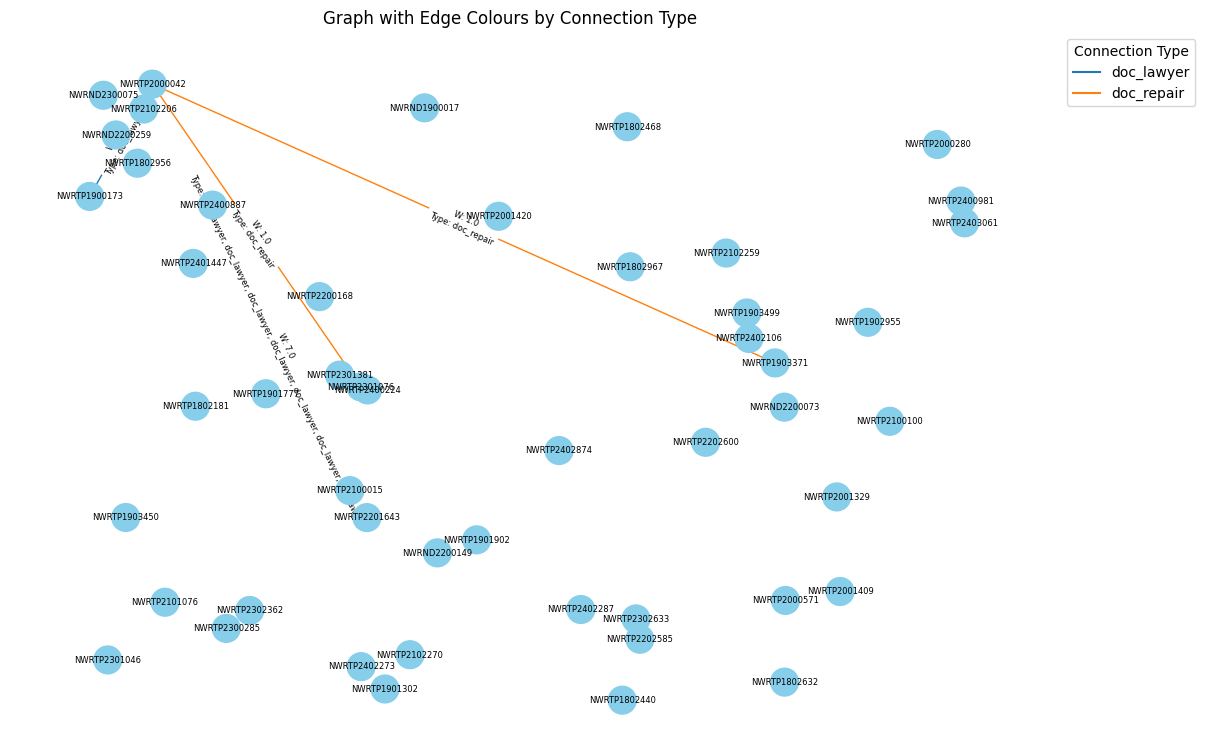

In [149]:
visualize_G(G_sub)

In [150]:
edge_index = data.edge_index
num_nodes = data.num_nodes

# Calculate the degree of each node
node_degrees = degree(edge_index[0], num_nodes=num_nodes)
node_degrees

tensor([1., 1., 1.,  ..., 1., 1., 6.])

In [151]:
save_data(G, conf.data_path, 'ctp_network', data_extension='pkl')

Data saved successfully locally as pickle: C:\GitHub\CTP_syndicate_model\data\ctp_network.pkl


In [152]:
save_data(all_nodes_df, conf.data_path, 'node_data', data_extension='csv')

Data saved successfully locally as CSV: C:\GitHub\CTP_syndicate_model\data\node_data.csv


### 2.5 Investigated Graph Analysis

In [153]:
# graph = load_data(conf.data_path, 'ctp_network', data_extension='pkl')

Nodes in the subgraph: [(14345, {'x': [1078.0, 35.0, 0.0, 1.0, 1.0, 0.0, 50.58000183105469, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], 'y': 1, 'claim_number': 'NWRTP2200385', 'policy_number': 'CTP594435473', 'claim_lodgement_date': datetime.date(2022, 3, 4), 'claim_loss_date': datetime.date(2021, 11, 11), 'claim_status_name': 'Closed', 'investigation_flag': 1, 'triage_flag': 1, 'alleged_flag': 1}), (21003, {'x': [404.0, 21.0, 195.0, 1.0, 1.0, 0.0, 1691.5400390625, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0], 'y': 1, 'claim_number': 'NWRTP2401085', 'policy_number': 'CTP644396458', 'claim_lodgement_date': datetime.date(2024, 4, 30), 'claim_loss_date': datetime.date(2024, 4, 24), 'claim_status_name': 'Open', 'investigation_flag': 1, 'triage_flag': 1, 'alleged_flag': 0}), (17936, {'x': [371.0, 4.0, 110.0, 0.0, 0.0, 0.0, 572.8800048828125, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], 'y': 1, 'claim_number': 'NWR

C:\Users\s745998\AppData\Local\Temp\ipykernel_19252\2990248004.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


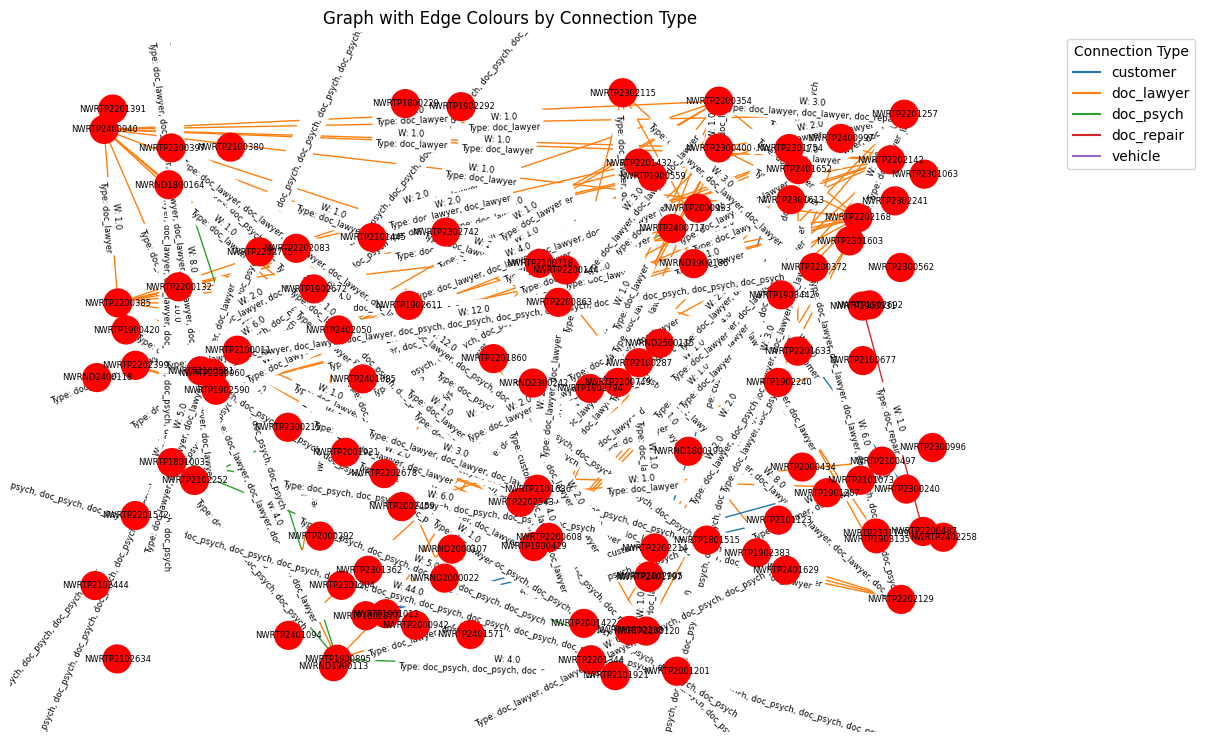

In [154]:
nodes_with_y_1 = [n for n, attr in G.nodes(data=True) if attr.get("y") == 1]
subG = G.subgraph(nodes_with_y_1)

# Output the nodes and edges of the subgraph
print(f"Nodes in the subgraph: {subG.nodes(data=True)}")
print(f"Edges in the subgraph: {subG.edges()}")

# Draw the subgraph

visualize_G(subG)


In [155]:
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities

# Find the communities using greedy modularity maximization
communities = greedy_modularity_communities(subG,weight='edge_weight')
# communities =louvain_communities(subG, resolution=0.5)

# Convert the result to a list of sets of nodes
communities = list(communities)
for i, community in enumerate(communities):
    print(f"Community {i+1}: {community}")

Community 1: frozenset({14345, 21963, 21012, 7318, 11864, 5855, 16095, 14821, 21543, 14567, 14314, 12779, 15214, 16630, 17142, 5432, 16121, 1852, 20861, 21566})
Community 2: frozenset({7394, 9412, 15589, 2885, 3370, 15499, 11727, 5746, 17139, 20916, 510, 1599})
Community 3: frozenset({16352, 18848, 16036, 16167, 11434, 12589, 16495, 16082, 14332})
Community 4: frozenset({14081, 18338, 15301, 11110, 15815, 18489})
Community 5: frozenset({9632, 10129, 7507, 5317, 11895})
Community 6: frozenset({10665, 11643, 11823})
Community 7: frozenset({12218, 4667, 12268})
Community 8: frozenset({9146, 16982})
Community 9: frozenset({14446, 8015})
Community 10: frozenset({17936, 20639})
Community 11: frozenset({15389, 16726})
Community 12: frozenset({21003})
Community 13: frozenset({19473})
Community 14: frozenset({17941})
Community 15: frozenset({18972})
Community 16: frozenset({16957})
Community 17: frozenset({594})
Community 18: frozenset({13394})
Community 19: frozenset({2154})
Community 20: froz

In [156]:
# def visualize_community(G, communities, community_idx):
#     import matplotlib.pyplot as plt
#     import networkx as nx

#     # Create a subgraph containing only the nodes in the cluster
#     selected_community = communities[community_idx]
#     community_subgraph = G.subgraph(selected_community)

#     # Create a color map for nodes based on an attribute 'y'
#     color_map = []
#     for node in community_subgraph.nodes(data=True):
#         if node[1].get('y') == 1:
#             color_map.append('red')
#         else:
#             color_map.append('skyblue')

#     # Create edge labels that combine the edge weight and connection_type
#     edge_labels = {}
#     for u, v, data in community_subgraph.edges(data=True):
#         weight = data.get('edge_weight', None)
#         connection_type = data.get('connection_type', None)

#         label_parts = []
#         if weight is not None:
#             label_parts.append(f"W: {weight}")
#         if connection_type:
#             label_parts.append(f"Type: {', '.join(connection_type)}")

#         edge_labels[(u, v)] = '\n'.join(label_parts) if label_parts else ''

#     # Plot the subgraph for the selected community
#     pos = nx.kamada_kawai_layout(community_subgraph)
#     plt.figure(figsize=(6, 4))
#     nx.draw(community_subgraph, pos, with_labels=False, node_color=color_map,
#             edge_color='grey', node_size=400, font_size=6)
#     nx.draw_networkx_edge_labels(community_subgraph, pos, edge_labels=edge_labels,
#                                  font_size=6, label_pos=0.5)
#     nx.draw_networkx_labels(community_subgraph, pos, labels={
#         node: data.get('claim_number', str(node)) for node, data in community_subgraph.nodes(data=True)
#     }, font_size=6)
#     plt.title(f'Subgraph for Community {community_idx}')
#     plt.show()



In [157]:
def visualize_community(G, communities, community_idx):
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Build the subgraph for this community ---
    selected = communities[community_idx]
    C = G.subgraph(selected)

    # --- Node colours based on 'y' ---
    node_colors = [
        'red' if data.get('y') == 1 else 'skyblue'
        for _, data in C.nodes(data=True)
    ]

    # --- Edge labels (
    # 
    #  + connection_type) ---
    edge_labels = {}
    for u, v, data in C.edges(data=True):
        parts = []
        if 'edge_weight' in data:
            parts.append(f"W: {data['edge_weight']}")
        ct = data.get('connection_type')
        if ct:
            if isinstance(ct, (list, tuple, set)):
                parts.append("Type: " + ", ".join(map(str, ct)))
            else:
                parts.append("Type: " + str(ct))
        edge_labels[(u, v)] = "\n".join(parts)

    # --- Gather unique connection types ---
    conn_types = set()
    for _, _, data in C.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)):
            conn_types.update(ct)
        elif ct is not None:
            conn_types.add(ct)

    # --- Map each type to a colour from tab10 ---
    cmap = plt.get_cmap('tab10')
    type_to_color = {
        ct: cmap(i % cmap.N)
        for i, ct in enumerate(sorted(conn_types))
    }
    default_edge_color = 'grey'

    # --- Build per-edge colour list ---
    edge_colors = []
    for _, _, data in C.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)) and ct:
            key = next(iter(ct))
            edge_colors.append(type_to_color.get(key, default_edge_color))
        elif ct is not None:
            edge_colors.append(type_to_color.get(ct, default_edge_color))
        else:
            edge_colors.append(default_edge_color)

    # --- Draw ---
    pos = nx.kamada_kawai_layout(C)
    plt.figure(figsize=(6, 4))
    nx.draw(
        C, pos,
        node_color=node_colors,
        edge_color=edge_colors,
        with_labels=False,
        node_size=400
    )
    # nx.draw_networkx_edge_labels(
    #     C, pos,
    #     edge_labels=edge_labels,
    #     font_size=6,
    #     label_pos=0.5
    # )
    nx.draw_networkx_labels(
        C, pos,
        labels={n: d.get('claim_number', str(n)) for n, d in C.nodes(data=True)},
        font_size=6
    )

    # --- Legend for types ---
    for ct, col in type_to_color.items():
        plt.plot([], [], color=col, label=str(ct))
    plt.legend(title="Connection Type", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(f"Subgraph for Community {community_idx}")
    plt.tight_layout()
    plt.show()


C:\Users\s745998\AppData\Local\Temp\ipykernel_19252\1197821059.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


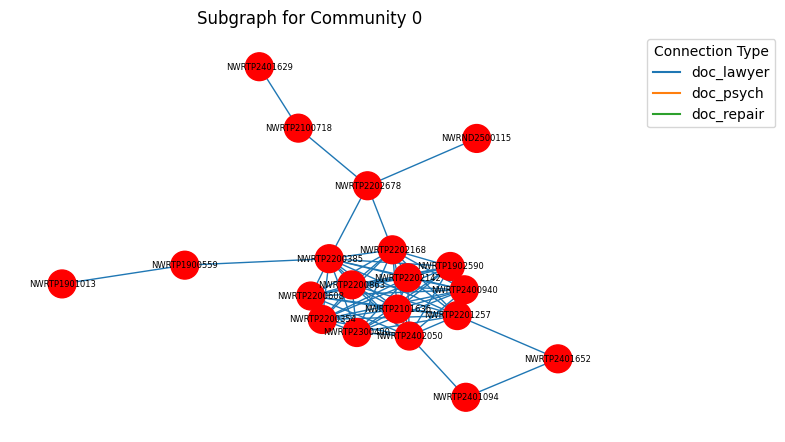

In [158]:
visualize_community(G, communities, 0)

C:\Users\s745998\AppData\Local\Temp\ipykernel_19252\1197821059.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


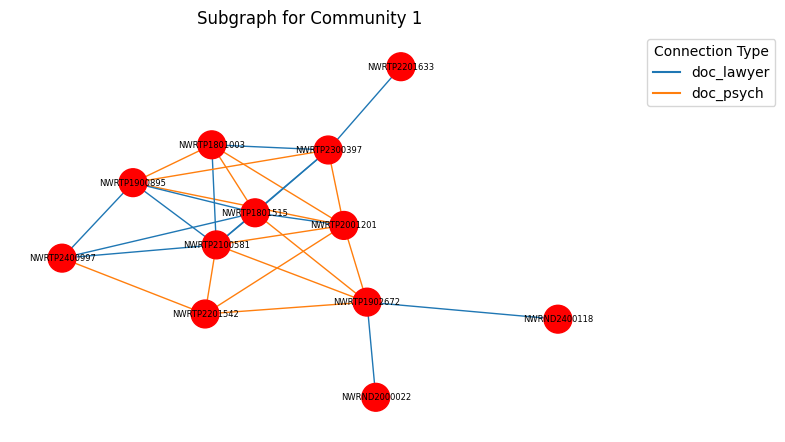

In [159]:
visualize_community(G, communities, 1)

C:\Users\s745998\AppData\Local\Temp\ipykernel_19252\1197821059.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


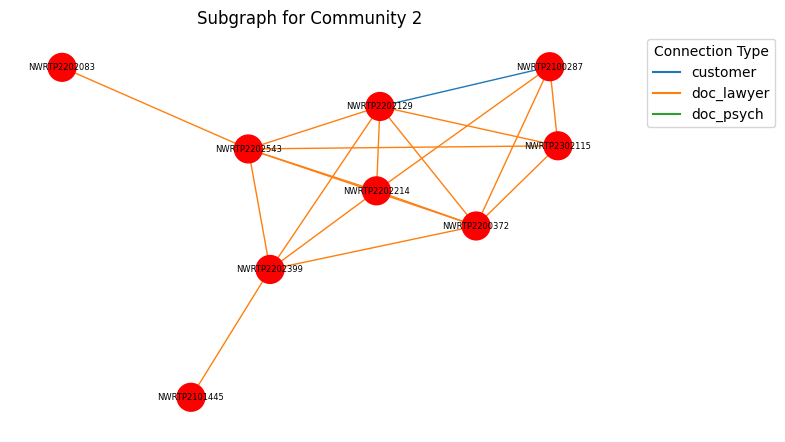

In [160]:
visualize_community(G, communities, 2)


### 2.6 Community Detection

In [161]:
def recursive_community_detection(G, communities_list,resolution,threshold,seed_value=42):

    random.seed(seed_value)
    np.random.seed(seed_value)
    # If the graph has 50 or fewer nodes, append it to the final communities list
    if G.number_of_nodes() <= threshold:
        communities_list.append(set(G.nodes))
    else:
        # Perform community detection on the subgraph
        # communities = nx.community.greedy_modularity_communities(G, weight='edge_weight', resolution=resolution)
        communities = louvain_communities(G, weight='edge_weight', resolution=resolution, seed=seed_value)
        
        # Apply the function recursively on the detected communities
        for community in communities:
            subgraph = G.subgraph(community)
            recursive_community_detection(subgraph, communities_list,resolution=resolution,threshold=threshold)

In [162]:
final_communities=[]
recursive_community_detection(G, final_communities, resolution=1.2, threshold=30)

len(final_communities)

1041

In [163]:
# final_communities = louvain_communities(G, weight='edge_weight', resolution=1, seed=42)
# len(final_communities)

In [164]:
community_sizes = [len(c) for c in final_communities]
max(community_sizes)

30

In [165]:
# filtered_communities = []

# for community in final_communities:
#     # Check if any node in the community has attribute 'y' = 1
#     if any(G.nodes[node].get('y') == 1 for node in community):
#         filtered_communities.append(community)

### 2.7 Community Analysis

In [166]:
from collections import Counter

# community_data = []

# for idx, community in enumerate(final_communities):
#     subgraph = G.subgraph(community)
#     node_list = [node for node, data in subgraph.nodes(data=True)]
#     claim_list = [data['claim_number'] for node, data in subgraph.nodes(data=True)]

#     community_edges = [
#         (u, v) for u, v in G.edges(community)
#         if u in community and v in community
#     ]

#     # Containers for attributes
#     customer_names = []
#     customer_numbers = []
#     connection_types = []
#     doctor_names = []
#     doctor_numbers = []
#     lawyer_names = []
#     lawyer_numbers = []
#     psych_names = []
#     psych_numbers = []
#     repairer_codes = []
#     rego_numbers = []

#     for u, v in community_edges:
#         attr = G.edges[u, v]

#         def collect(field, container):
#             val = attr.get(field)
#             if isinstance(val, (set, list)):
#                 container.extend(val)
#             elif val:
#                 container.append(val)

#         collect('connection_type', connection_types)
#         collect('cust_contact_name', customer_names)
#         collect('cust_contact_number', customer_numbers)
#         collect('doctor_contact_name', doctor_names)
#         collect('doctor_contact_number', doctor_numbers)
#         collect('lawyer_contact_name', lawyer_names)
#         collect('lawyer_contact_number', lawyer_numbers)
#         collect('psych_contact_name', psych_names)
#         collect('psych_contact_number', psych_numbers)
#         collect('repairer_code', repairer_codes)
#         collect('rego_number', rego_numbers)

#     # Helper to get most common value and count
#     def most_common(counter_list):
#         counter = Counter(counter_list)
#         return counter.most_common(1)[0] if counter else (None, 0)

#     # Get most common values
#     conn_val, conn_count = most_common(connection_types)
#     name_val, name_count = most_common(customer_names)
#     number_val, number_count = most_common(customer_numbers)
#     doc_name_val, doc_name_count = most_common(doctor_names)
#     doc_number_val, doc_number_count = most_common(doctor_numbers)
#     lawyer_name_val, lawyer_name_count = most_common(lawyer_names)
#     lawyer_number_val, lawyer_number_count = most_common(lawyer_numbers)
#     psych_name_val, psych_name_count = most_common(psych_names)
#     psych_number_val, psych_number_count = most_common(psych_numbers)
#     repairer_code_val, repairer_code_count = most_common(repairer_codes)
#     rego_number_val, rego_number_count = most_common(rego_numbers)

#     community_data.append({
#         'community_index': idx,
#         'node_indexes': node_list,
#         'claim_numbers': claim_list,

#         'most_frequent_connection_type': conn_val,
#         'connection_count': conn_count,

#         'most_frequent_customer_name': name_val,
#         'customer_name_count': name_count,

#         'most_frequent_customer_number': number_val,
#         'customer_number_count': number_count,

#         'most_frequent_doctor_name': doc_name_val,
#         'doctor_name_count': doc_name_count,

#         'most_frequent_doctor_number': doc_number_val,
#         'doctor_number_count': doc_number_count,

#         'most_frequent_lawyer_name': lawyer_name_val,
#         'lawyer_name_count': lawyer_name_count,

#         'most_frequent_lawyer_number': lawyer_number_val,
#         'lawyer_number_count': lawyer_number_count,

#         'most_frequent_psych_name': psych_name_val,
#         'psych_name_count': psych_name_count,

#         'most_frequent_psych_number': psych_number_val,
#         'psych_number_count': psych_number_count,

#         'most_frequent_repairer_code': repairer_code_val,
#         'repairer_code_count': repairer_code_count,

#         'most_frequent_rego_number': rego_number_val,
#         'rego_number_count': rego_number_count,
#     })

# # Convert to DataFrame
# community_df = pd.DataFrame(community_data)


In [167]:
# community_df.set_index('community_index', inplace=True)
# community_df

In [168]:
# Function to compute conductance
def compute_conductance(graph, community):
    vol_community = sum(dict(graph.degree(community)).values())
    edge_boundary = len(list(nx.edge_boundary(graph, community)))
    vol_rest = sum(dict(graph.degree(graph.nodes - community)).values())

    if vol_community>0 and vol_rest>0:  
        return edge_boundary / min(vol_community, vol_rest)  
    else:
        return 0

In [169]:
def cal_metrics_community(G, communities):   
    # Collect metrics for each community
    community_metrics = []

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)

        edge_weights = [data.get('edge_weight', 0) for u, v, data in subgraph.edges(data=True)]
        total_weight = sum(edge_weights)
        avg_edge_weight = total_weight / len(edge_weights) if edge_weights else 0

        node_list=[node for node, data in subgraph.nodes(data=True)]
        # Retrieve claim numbers:
        claim_list=[data['claim_number']for node, data in subgraph.nodes(data=True)]

        investigation_list = [data['investigation_flag'] for node, data in subgraph.nodes(data=True) if data['investigation_flag'] != 0]
        
        triage_list = [data['triage_flag'] for node, data in subgraph.nodes(data=True) if data['triage_flag'] != 0]
        
        allege_list = [data['alleged_flag'] for node, data in subgraph.nodes(data=True) if data['alleged_flag'] != 0]

        # Clustering coefficient (average for nodes in the community)
        avg_clustering = nx.average_clustering(subgraph)
        
        # Conductance
        conductance = compute_conductance(G, community)
        
        # Density
        density = nx.density(subgraph)
        
        # Triangle count (sum of triangles in the community)
        triangles = sum(nx.triangles(subgraph).values()) // 3  # Each triangle is counted thrice

        # Calculate percentage of nodes with y == 1
        total_nodes = len(community)
        y_count = sum(1 for node, data in subgraph.nodes(data=True) if data.get('y', 0) == 1)
        y_percentage = (y_count / total_nodes * 100) if total_nodes > 0 else 0
        
        # Add metrics to the list
        community_metrics.append({
            'Community': i,
            'Nodes': node_list,
            'Claim Numbers': claim_list,
            'Average edge weight':avg_edge_weight,
            'Investigated count': len(investigation_list),
            'Triaged count':len(triage_list),
            'Alleged count':len(allege_list),
            'Clustering Coefficient': avg_clustering,
            'Conductance': conductance,
            'Density': density,
            'Triangle Count': triangles,
            'Size': len(community),
            'investigation_rate': y_percentage # Optionally add community size
        })

    # Create a DataFrame
    df_metrics = pd.DataFrame(community_metrics)
    return df_metrics

In [170]:
df_metrics = cal_metrics_community(G, final_communities)
df_metrics

,Community,Nodes,Claim Numbers,Average edge weight,Investigated count,Triaged count,Alleged count,Clustering Coefficient,Conductance,Density,Triangle Count,Size,investigation_rate
0,0,"[8, 19499, 7]","[DPNTP2400009, NWRTP2302768, DPNTP2400008]",4.000,0,1,0,1.000,0.000,1.000,1,3,0.000
1,1,"[23945, 11, 12549]","[NWRTP2500485, DPNTP2500001, NWRTP2101405]",3.333,0,0,0,1.000,0.000,1.000,1,3,0.000
2,2,"[10722, 36, 10405, 40, 17, 16370, 10417, 10708...","[NWRTP2002516, NWRND1800024, NWRTP2002198, NWR...",2.000,0,0,0,1.000,0.000,1.000,364,14,0.000
3,3,[13569],[NWRTP2102428],0.000,0,0,0,0.000,1.000,0.000,0,1,0.000
4,4,[13316],[NWRTP2102174],0.000,0,0,0,0.000,1.000,0.000,0,1,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,1036,"[8545, 21892, 3246, 7662, 24409, 21532]","[NWRTP2000320, NWRTP2401979, NWRTP1801385, NWR...",2.444,0,0,0,0.900,0.250,0.600,5,6,0.000
1037,1037,[24439],[NWRTP2500979],0.000,0,0,0,0.000,0.000,0.000,0,1,0.000
1038,1038,[24442],[NWRTP2500982],0.000,0,0,0,0.000,0.000,0.000,0,1,0.000
1039,1039,[24473],[NWRTP2501013],0.000,0,0,0,0.000,0.000,0.000,0,1,0.000


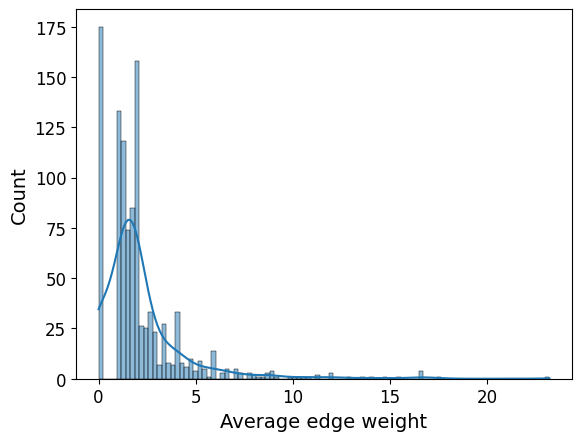

In [171]:
sns.histplot(df_metrics['Average edge weight'], kde=True, bins=100) 
plt.show()

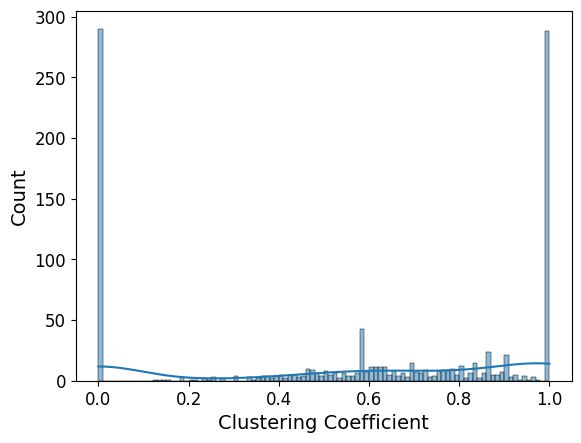

In [172]:
sns.histplot(df_metrics['Clustering Coefficient'], kde=True, bins=100) 
plt.show()

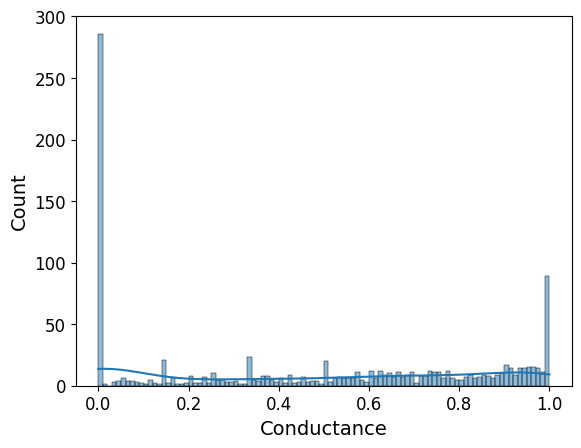

In [173]:
sns.histplot(df_metrics['Conductance'], kde=True, bins=100) 
plt.show()

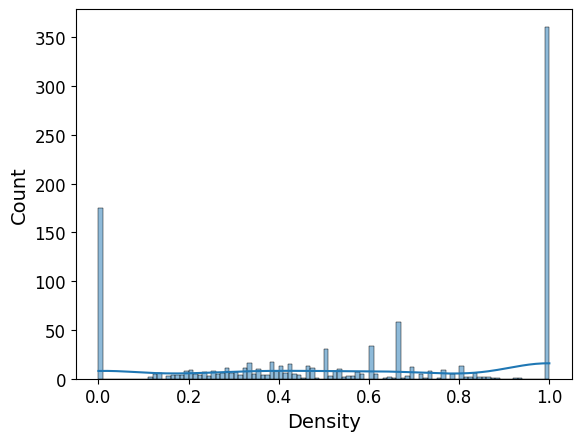

In [174]:
sns.histplot(df_metrics['Density'], kde=True, bins=100) 
plt.show()

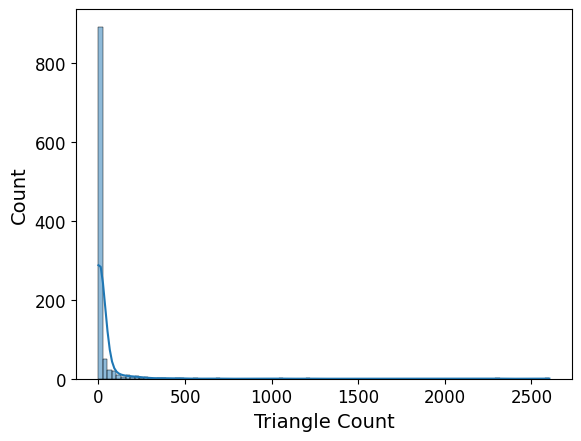

In [175]:
sns.histplot(df_metrics['Triangle Count'], kde=True, bins=100) 
plt.show()

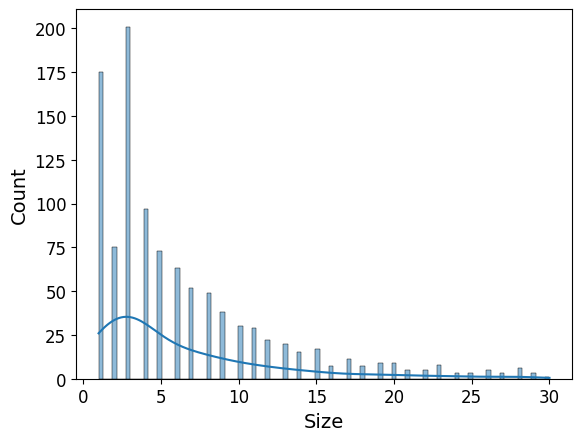

In [176]:
sns.histplot(df_metrics['Size'], kde=True, bins=100) 
plt.show()

In [177]:
# Filter communities based on criteria 
filtered_metrics = df_metrics[
    (df_metrics['Clustering Coefficient'] > 0.8) &  
    # (df_metrics['Conductance'] < 0.8) &             
    (df_metrics['Density'] > 0.8) &                 
    (df_metrics['Triangle Count'] > 2) &
    (df_metrics['Size'] >=4 ) &
    (df_metrics['Size'] <=30)         
].reset_index(drop=True)  

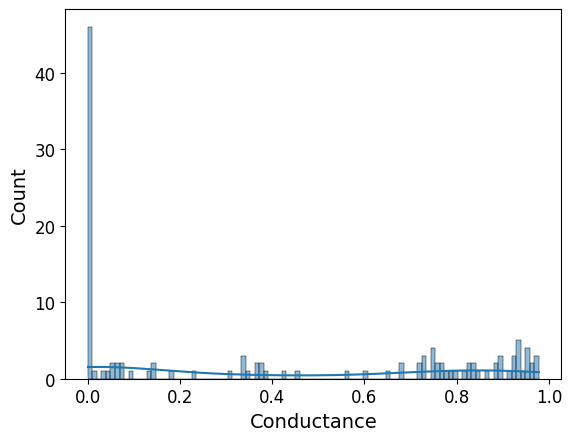

In [178]:
sns.histplot(filtered_metrics['Conductance'], kde=True, bins=100) 
plt.show()

In [179]:
ranked_metrics = filtered_metrics.sort_values(by=['Size','Clustering Coefficient','Density','Conductance'], ascending=[False,False,False,True]).reset_index(drop=True)
filtered_communities = ranked_metrics['Nodes'].tolist()
len(filtered_communities)

125

In [180]:
df_filtered_metrics = cal_metrics_community(G, filtered_communities)
df_filtered_metrics

,Community,Nodes,Claim Numbers,Average edge weight,Investigated count,Triaged count,Alleged count,Clustering Coefficient,Conductance,Density,Triangle Count,Size,investigation_rate
0,0,"[1153, 6792, 16142, 15762, 7706, 8731, 6173, 9...","[NWRND2200211, NWRTP1902020, NWRTP2202189, NWR...",1.384,0,3,0,0.950,0.351,0.815,2604,29,0.000
1,1,"[7553, 14345, 5387, 2839, 414, 4265, 5806, 122...","[NWRTP1902845, NWRTP2200385, NWRTP1900509, NWR...",2.762,2,3,1,0.994,0.732,0.929,2301,26,7.692
2,2,"[20704, 16449, 19650, 11587, 12707, 11491, 158...","[NWRTP2400782, NWRTP2202497, NWRTP2302919, NWR...",1.559,0,1,0,1.000,0.720,1.000,680,17,0.000
3,3,"[9760, 12377, 23586, 11171, 13124, 11974, 1626...","[NWRTP2001552, NWRTP2101233, NWRTP2500126, NWR...",1.083,0,3,0,0.934,0.754,0.890,560,17,0.000
4,4,"[15072, 15905, 21890, 21796, 18664, 7880, 1377...","[NWRTP2201115, NWRTP2201951, NWRTP2401977, NWR...",1.000,0,2,0,1.000,0.765,1.000,455,15,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,120,"[21953, 10476, 17109, 16926]","[NWRTP2402040, NWRTP2002269, NWRTP2300367, NWR...",2.000,0,0,0,1.000,0.897,1.000,4,4,0.000
121,121,"[1384, 7795, 620, 9812]","[NWRND2300160, NWRTP1903104, NWRND2000133, NWR...",1.167,0,1,0,1.000,0.910,1.000,4,4,0.000
122,122,"[9112, 12027, 21972, 17789]","[NWRTP2000899, NWRTP2100882, NWRTP2402059, NWR...",1.000,0,0,0,1.000,0.952,1.000,4,4,0.000
123,123,"[22338, 14139, 21964, 17541]","[NWRTP2402428, NWRTP2200178, NWRTP2402051, NWR...",3.000,0,2,0,1.000,0.957,1.000,4,4,0.000


In [181]:

# def generate_output(G, communities):
#     """
#     Given a NetworkX graph G and a list of communities (each a list of node IDs),
#     returns a DataFrame with one row per undirected edge–relationship pair:
#       Community_id | Claim 1 | Claim 2 | Relationship Type | Relationship Party

#     Assumes:
#       - G.nodes[u]['claim_number'] exists for every node u
#       - G.edges[u, v]['connection_type'] is a set of types
#       - G.edges[u, v] may contain:
#           cust_contact_name (str or set of str),
#           doctor_contact_name (str or set of str),
#           lawyer_contact_name,
#           psych_contact_name,
#           repair_contact_name,
#           rego_number (str or set of str)
#     """
#     def normalize_field(val):
#         """Join iterable of strings, or return string."""
#         if isinstance(val, (set, list, tuple)):
#             return ", ".join(val)
#         return val if val is not None else ""

#     rows = []
#     for community_id, community in enumerate(communities):
#         sub = G.subgraph(community)
#         seen = set()
        
#         for u, v, edge_data in sub.edges(data=True):
#             conn_types = edge_data.get('connection_type', set())
#             for rel in conn_types:
#                 key = tuple(sorted((u, v))) + (rel,)
#                 if key in seen:
#                     continue
#                 seen.add(key)
                
#                 # prepare party based on relationship type
#                 if rel == 'customer':
#                     party = normalize_field(edge_data.get('cust_contact_name'))
#                 elif rel == 'doc_lawyer':
#                     party = (
#                         "doctor: " + normalize_field(edge_data.get('doctor_contact_name')),
#                         "lawyer: " + normalize_field(edge_data.get('lawyer_contact_name'))
#                     )
#                 elif rel == 'doc_psych':
#                     party = (
#                         "doctor: " + normalize_field(edge_data.get('doctor_contact_name')),
#                         "psych: "  + normalize_field(edge_data.get('psych_contact_name'))
#                     )
#                 elif rel == 'doc_repair':
#                     party = (
#                         "doctor: " + normalize_field(edge_data.get('doctor_contact_name')),
#                         "repair: " + normalize_field(edge_data.get('repair_contact_name'))
#                     )
#                 elif rel == 'vehicle':
#                     party = normalize_field(edge_data.get('rego_number'))
#                 else:
#                     party = None
                
#                 rows.append({
#                     'Community_id':       community_id,
#                     'Claim 1':            G.nodes[u]['claim_number'],
#                     'Claim 2':            G.nodes[v]['claim_number'],
#                     'Relationship Type':  rel,
#                     'Relationship Party': party
#                 })
    
#     return pd.DataFrame(rows)

# Usage:
# edges_df = generate_output(G, filtered_communities)
# print(edges_df)
# edges_df.to_csv('community_edge_relationships.csv', index=False)



In [182]:
def generate_output(G, communities):
    """
    Given a NetworkX graph G and a list of communities (each a list of node IDs),
    returns a DataFrame with one row per undirected edge–relationship pair:
      Community_id | Claim 1 | Claim 2 | Relationship Type | Relationship Party

    Assumes:
      - G.nodes[u]['claim_number'] exists for every node u
      - G.edges[u, v]['connection_type'] is a set of types
      - G.edges[u, v] may contain:
          cust_contact_name (str or set of str),
          doctor_contact_name (str or set of str),
          lawyer_contact_name,
          psych_contact_name,
          repair_contact_name,
          rego_number (str or set of str)
    """

    rows = []
    for community_id, community in enumerate(communities):
        sub = G.subgraph(community)
        seen = set()
        
        for u, v, edge_data in sub.edges(data=True):
            conn_types = edge_data.get('connection_type', list())
            for i, rel in enumerate(conn_types):
                key = tuple(sorted((u, v))) + (rel,)
                if key in seen:
                    continue
                seen.add(key)
                party= edge_data.get('party_name', list())[i]
                # prepare party based on relationship type
                               
                rows.append({
                    'Community_id':       community_id,
                    'Claim 1':            G.nodes[u]['claim_number'],
                    'Claim 2':            G.nodes[v]['claim_number'],
                    'Relationship Type':  rel,
                    'Relationship Party': party
                })
    
    return pd.DataFrame(rows)

In [183]:
output_df=generate_output(G, filtered_communities)
output_df

,Community_id,Claim 1,Claim 2,Relationship Type,Relationship Party
0,0,NWRND2200211,NWRTP1901358,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ..."
1,0,NWRND2200211,NWRTP1901680,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ..."
2,0,NWRND2200211,NWRTP1902020,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ..."
3,0,NWRND2200211,NWRTP1902133,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ..."
4,0,NWRND2200211,NWRTP1902490,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ..."
...,...,...,...,...,...
3373,124,NWRTP2303134,NWRTP2400130,doc_psych,"(doctor: Eric Lim, psych: Workers Doctors)"
3374,124,NWRTP2400116,NWRTP2302104,doc_lawyer,"(doctor: Morgan Mo, lawyer: Benefit Legal Lawy..."
3375,124,NWRTP2400116,NWRTP2400130,doc_lawyer,"(doctor: Eric Lim, lawyer: Benefit Legal Lawye..."
3376,124,NWRTP2302104,NWRTP2400130,doc_lawyer,"(doctor: Morgan Mo, lawyer: Benefit Legal Lawy..."


In [184]:
# rename df_encoded for Claim 1
df1 = df_encoded.rename(columns={
    'claim_number':           'Claim 1',
    'claim_lodgement_date':   'Claim 1 lodgement date',
    'claim_status_name':      'Claim 1 status'
})

# then rename df_encoded for Claim 2
df2 = df_encoded.rename(columns={
    'claim_number':           'Claim 2',
    'claim_lodgement_date':   'Claim 2 lodgement date',
    'claim_status_name':      'Claim 2 status'
})

# now merge onto output_df
df_output_merged = (
    output_df
    .merge(df1[['Claim 1','Claim 1 lodgement date','Claim 1 status']],
           on='Claim 1', how='left')
    .merge(df2[['Claim 2','Claim 2 lodgement date','Claim 2 status']],
           on='Claim 2', how='left')
)

new_order = [
    'Community_id',
    'Claim 1', 'Claim 1 lodgement date', 'Claim 1 status',
    'Claim 2', 'Claim 2 lodgement date', 'Claim 2 status',
    'Relationship Type', 'Relationship Party'
]

df_output_merged = df_output_merged[new_order]
df_output_merged['created date'] = date.today()
# inspect
df_output_merged.head()


,Community_id,Claim 1,Claim 1 lodgement date,Claim 1 status,Claim 2,Claim 2 lodgement date,Claim 2 status,Relationship Type,Relationship Party,created date
0,0,NWRND2200211,2022-09-29,Open,NWRTP1901358,2019-05-27,Closed,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ...",2025-07-09
1,0,NWRND2200211,2022-09-29,Open,NWRTP1901680,2019-06-26,Closed,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ...",2025-07-09
2,0,NWRND2200211,2022-09-29,Open,NWRTP1902020,2019-07-29,Closed,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ...",2025-07-09
3,0,NWRND2200211,2022-09-29,Open,NWRTP1902133,2019-08-06,Closed,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ...",2025-07-09
4,0,NWRND2200211,2022-09-29,Open,NWRTP1902490,2019-09-12,Closed,doc_repair,"(doctor: John Hunter Hospital, repairer_name: ...",2025-07-09


In [185]:
table_schema='dl_aai_sqd_claim'
table_name ='ctp_syndicate_output'
sql(conf=conf, fn="write", sql=None, schema=table_schema, name=table_name, value=df_output_merged, method='replace')
output_df.to_csv('community_output_new.csv', index=False)

In [186]:

ranked_metrics.head(10)

,Community,Nodes,Claim Numbers,Average edge weight,Investigated count,Triaged count,Alleged count,Clustering Coefficient,Conductance,Density,Triangle Count,Size,investigation_rate
0,497,"[1153, 6792, 16142, 15762, 7706, 8731, 6173, 9...","[NWRND2200211, NWRTP1902020, NWRTP2202189, NWR...",1.384,0,3,0,0.950,0.351,0.815,2604,29,0.000
1,903,"[7553, 14345, 5387, 2839, 414, 4265, 5806, 122...","[NWRTP1902845, NWRTP2200385, NWRTP1900509, NWR...",2.762,2,3,1,0.994,0.732,0.929,2301,26,7.692
2,536,"[20704, 16449, 19650, 11587, 12707, 11491, 158...","[NWRTP2400782, NWRTP2202497, NWRTP2302919, NWR...",1.559,0,1,0,1.000,0.720,1.000,680,17,0.000
3,535,"[9760, 23586, 11171, 13124, 11974, 16264, 1580...","[NWRTP2001552, NWRTP2500126, NWRTP2100022, NWR...",1.083,0,3,0,0.934,0.754,0.890,560,17,0.000
4,780,"[15072, 15905, 21890, 15710, 21796, 18664, 788...","[NWRTP2201115, NWRTP2201951, NWRTP2401977, NWR...",1.000,0,2,0,1.000,0.765,1.000,455,15,0.000
5,2,"[10722, 36, 10405, 40, 17, 16370, 10417, 10708...","[NWRTP2002516, NWRND1800024, NWRTP2002198, NWR...",2.000,0,0,0,1.000,0.000,1.000,364,14,0.000
6,156,"[19361, 5122, 16801, 22116, 16485, 19656, 1825...","[NWRTP2302630, NWRTP1900219, NWRTP2300059, NWR...",4.446,0,3,0,0.881,0.823,0.813,241,14,0.000
7,545,"[10272, 227, 968, 10184, 11832, 6411, 10956, 3...","[NWRTP2002065, NWRND1800217, NWRND2200026, NWR...",1.295,0,1,0,1.000,0.678,1.000,286,13,0.000
8,291,"[5760, 3075, 266, 7691, 7341, 4621, 9524, 2357...","[NWRTP1900910, NWRTP1801207, NWRND1900027, NWR...",1.397,0,0,0,0.977,0.373,0.872,221,13,0.000
9,772,"[18368, 6760, 20393, 11019, 7180, 19342, 14995...","[NWRTP2301633, NWRTP1901987, NWRTP2400469, NWR...",1.343,0,1,0,0.910,0.783,0.859,220,13,0.000


In [187]:
# output_df.index.name = 'community_id'

# # Perform the join by resetting the index so we can join on it like a regular column
# merged_df = output_df.reset_index().merge(
#     ranked_metrics,
#     how='inner',
#     left_on='community_index',
#     right_on='Community'
# )
# merged_df.head(10)

In [188]:
# merged_df.drop(columns=['Community','Nodes', 'Claim Numbers'], inplace=True)

C:\Users\s745998\AppData\Local\Temp\ipykernel_19252\1197821059.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


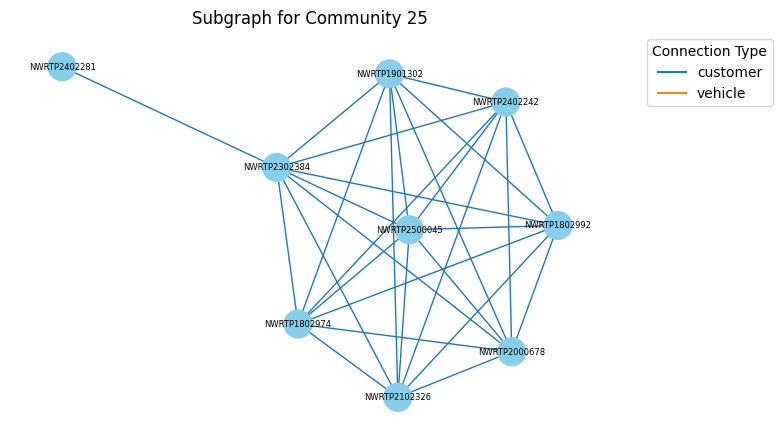

In [189]:
visualize_community(G, filtered_communities, 25)

# 3 Implement algorithms on Claim Network

In [190]:
import pytz
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, \
    f1_score, confusion_matrix, auc, precision_recall_curve,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
# from pygod.detector import DOMINANT
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data
from network import Dominant
import optuna

c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [191]:
# import torch
# import torch_geometric

# print("Torch version:", torch.__version__)
# print("Torch Geometric version:", torch_geometric.__version__)

### 3.1 Hyperparameter tuning on DOMINANT model

In [192]:
class networkEvaluator:
    """
    conf: from Conf class
    model_IF: isolation forest model
    x: input dataframe
    y: target value
    id_df: index columns of dataframe
    csv_filename: name of saving file
    thresh: threshold for model IF decision fucntion
    metric1: use as objective in HP, key in metrics dictionary
    metric2: use for comparison in plot, key in metrics dictionary
    """

    def __init__(self, conf):
        self.conf = conf

    @staticmethod
    def evaluate (conf, model, data, id_df, thresh, MODEL_TAG, csv_filename, metric1, metric2):
        anomaly_scores, y_emb=model.predict(data, get_emb=True)
        y_score = anomaly_scores.numpy()
        y_score = pd.Series(y_score, name='y_score')
        y_real= pd.Series(id_df['investigation_flag'], name='y')
        triage = pd.Series(id_df['triage_flag'], name='triage_flag')
        combined_df = pd.concat([y_score.reset_index(drop=True), 
                                 y_real.reset_index(drop=True), 
                                 triage.reset_index(drop=True)], axis=1)
        combined_df['y_pred'] = np.where(combined_df['y_score'] >= thresh, 1, 0)
        alert_vol =  sum(combined_df['y_pred'] == 1)
        inv_curr = sum(combined_df['y'])
        triage_curr = sum(combined_df['triage_flag'])

        t2i_curr = np.divide(inv_curr, triage_curr,
                                out=np.zeros_like(inv_curr, dtype=float), where=triage_curr != 0)

        inv_pred = sum(combined_df[combined_df['y_pred'] == 1]['y'])
        triage_pred = sum(combined_df[combined_df['y_pred'] == 1]['triage_flag'])

        t2i_pred = np.divide(inv_pred, triage_pred,
                                out=np.zeros_like(inv_pred, dtype=float), where=triage_pred != 0)
        
        precision = precision_score(combined_df['y'], combined_df['y_pred'])
        recall = recall_score(combined_df['y'], combined_df['y_pred'])
        f1 = f1_score(combined_df['y'], combined_df['y_pred'])
        conf_matrix = confusion_matrix(combined_df['y'], combined_df['y_pred'])
        precision2, recall2, _ = precision_recall_curve(combined_df['y'], combined_df['y_score'])
        pr_auc = auc(recall2, precision2)
        auc_roc_score = roc_auc_score(combined_df['y'], combined_df['y_score'])

        metrics = {
            "alert_vol": alert_vol,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Confusion Matrix": conf_matrix,
            "AUC-PR": pr_auc,
            "AUC-ROC": auc_roc_score,
            "Current T2I": t2i_curr,
            "New T2I": t2i_pred
        }
        # Print metrics
        print("Evaluation Metrics:")
        for metric_name, metric_value in metrics.items():
            print(f"{metric_name}: {metric_value}")
        
        # Save meitrics to CSV
        networkEvaluator.save_metrics_to_csv(MODEL_TAG, metrics,
                                                     metric1, metric2, csv_filename)
        return metrics, combined_df

    @staticmethod
    def save_metrics_to_csv(MODEL_TAG, metrics, metric1, metric2, csv_filename):
        try:
            metric_df = pd.read_csv(csv_filename)
        except FileNotFoundError:
            metric_df = pd.DataFrame(columns=['Model', metric1, metric2])

        new_row = pd.DataFrame({'Model': [MODEL_TAG], 
                                metric1: [metrics[metric1]], 
                                metric2: [metrics[metric2]]})
        
        metric_df = pd.concat([metric_df, new_row], ignore_index=True)
        metric_df.to_csv(csv_filename, index=False)


# evaluator for Random forest 

In [193]:

class networkTrainer:
    """
    use metric1 as objective
    use metirc2 as comparison in plot

    """
    def __init__(self, conf, data, id_train, metric1, metric2):
        self.conf = conf
        self.data = data
        self.id_train = id_train
        self.metric1 = metric1
        self.metric2 = metric2
        self.metric_results = []

    def objective(self, trial):
        # Suggest values for the hyperparameters
        hidden_size = trial.suggest_int('hidden_size', 5, self.data.x.shape[1], step=1 )
        num_epochs = trial.suggest_int('num_epochs', 100, 200, step=5 )
        learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1) 
        weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
        dropout = trial.suggest_uniform('dropout', 0, 0.5) 
        # Create the model with suggested hyperparameters
        params={
            'hidden_size': hidden_size,
            'num_epochs': num_epochs,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'dropout': 0
        }
        # threshold = trial.suggest_uniform('threshold', 0, 0.5)  # Optimize threshold
        MODEL_TAG = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
        model = self.train_model(self.data, params)
        metrics, combined_df = networkEvaluator.evaluate(self.conf, model, self.data, self.id_train, 
                        500, MODEL_TAG, self.conf.artefact_path + "/metrics_train.csv", 
                        self.metric1, self.metric2)
        # Save the metrics for later plotting
        self.metric_results.append({self.metric1:metrics[self.metric1], self.metric2:metrics[self.metric2]})
        return metrics[self.metric1]
    

    def train_model(self, data, params):
        model = Dominant(feat_size=data.x.shape[1], hidden_size=params['hidden_size'], dropout=params['dropout'])
        model.train_model(data, num_epochs=params['num_epochs'], learning_rate=params['learning_rate'], weight_decay=params['weight_decay'])
        return model

    def train_with_optuna(self, n_trials=50):
        study = optuna.create_study(direction='maximize')
        study.optimize(self.objective, n_trials)  # 100 trials

        best_params = study.best_params

        # Plot A2I and "New R2I" curves after all trials are finished
        self.plot_metrics_curve()

        return best_params, study

    def plot_metrics_curve(self):
        # Retrieve the desired metrics from the results
        metric1_values = [result[self.metric1] for result in self.metric_results]
        metric2_values = [result[self.metric2] for result in self.metric_results]
        trials = np.arange(1, len(metric1_values) + 1)

        # Plot the selected metrics
        plt.figure(figsize=(10, 6))
        plt.plot(trials, metric1_values, marker='o', linestyle='-', color='b', label=self.metric1)
        plt.plot(trials, metric2_values, marker='o', linestyle='-', color='r', label=self.metric2)
        plt.title('Performance Metrics for Hyperparameter Tuning Trials')
        plt.xlabel('Trial')
        plt.ylabel('Score')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
# init params
hptrial = 0 # number of trials in HP tuning
metric1 = 'New T2I' # use as objective in HP tuning
metric2 = 'AUC-PR'  # use for HP tuning tracking

# train_tag = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
print('*' * 60)
print('HP tuning started...')
# use New T2D as objective
# run on 2024-02-16
function_start_time = time.time()
# Instantiate the trainer
trainer = networkTrainer(conf, data, all_nodes_df, metric1, metric2)
# Train with Optuna
best_params, study = trainer.train_with_optuna(n_trials=hptrial)
trial_data = study.trials_dataframe()
# save_pkl(best_params, conf.artefact_path, "best_params", data_extension="pkl")
# save_pkl(trial_data, conf.artefact_path, "trial_data_{}".format(train_tag), data_extension="pkl")
print("Best Parameters:", best_params)
print('HP tuning finished...')
print('*' * 60)
elapsed_time('model HP tuning', project_start_time, function_start_time)

[I 2025-07-09 14:50:53,283] A new study created in memory with name: no-name-0ecf4ea0-1db1-4f08-8c66-4d3db34d4664


************************************************************
HP tuning started...


ValueError: No trials are completed yet.

### 3.2 Train model and extract network embeddings

In [195]:
# Initialize model
model = Dominant(feat_size=data.x.shape[1], hidden_size=5, dropout=0)
model.train_model(data, num_epochs=100, learning_rate=0.03412, weight_decay=9.673410564957844e-05)

Epoch 1/100, Loss: 423447616.00, Struct loss: 360087968.00, Attr loss: 63359.64
Epoch 2/100, Loss: 113723856.00, Struct loss: 53830536.00, Attr loss: 59893.32
Epoch 3/100, Loss: 65457468.00, Struct loss: 7625448.00, Attr loss: 57832.02
Epoch 4/100, Loss: 57262860.00, Struct loss: 726628.19, Attr loss: 56536.23
Epoch 5/100, Loss: 55729560.00, Struct loss: 19084.76, Attr loss: 55710.48
Epoch 6/100, Loss: 55181464.00, Struct loss: 0.00, Attr loss: 55181.46
Epoch 7/100, Loss: 54626900.00, Struct loss: 0.00, Attr loss: 54626.90
Epoch 8/100, Loss: 53983088.00, Struct loss: 0.00, Attr loss: 53983.09
Epoch 9/100, Loss: 53225552.00, Struct loss: 0.00, Attr loss: 53225.55
Epoch 10/100, Loss: 52224700.00, Struct loss: 0.00, Attr loss: 52224.70
Epoch 11/100, Loss: 50855876.00, Struct loss: 0.00, Attr loss: 50855.88
Epoch 12/100, Loss: 48949572.00, Struct loss: 0.00, Attr loss: 48949.57
Epoch 13/100, Loss: 45828340.00, Struct loss: 0.00, Attr loss: 45828.34
Epoch 14/100, Loss: 41807536.00, Struct l

Dominant(
  (shared_encoder): Encoder(
    (gc1): GCNConv(21, 5)
    (gc2): GCNConv(5, 5)
  )
  (attr_decoder): Attribute_Decoder(
    (gc1): GCNConv(5, 5)
    (gc2): GCNConv(5, 21)
  )
  (struct_decoder): Structure_Decoder(
    (gc1): GCNConv(5, 5)
  )
)

### 3.3 Evaluate graph anomaly detection model

In [196]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

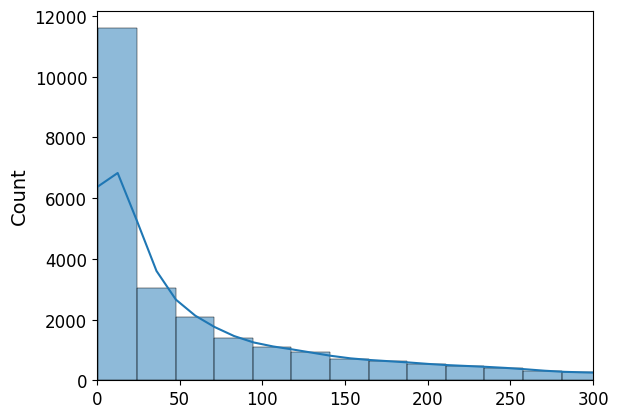

In [197]:
# Using seaborn's distplot for a more visual distribution plot
sns.histplot(anomaly_scores, kde=True, bins=100) 
plt.xlim(0,300) 
plt.show()

In [198]:
train_tag=datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')

In [199]:
all_metrics_dfs = []
for thresh in range(100,250, 10):
        metrics, combined_df = networkEvaluator.evaluate(conf,model, data, all_nodes_df, 
                          thresh, train_tag, conf.artefact_path + "/metrics_train.csv", 
                          'New T2I', 'AUC-PR')
                # Convert metrics dict to DataFrame (assuming keys are the metric names)
        metrics_df = pd.DataFrame([metrics])
        
        # Add a column for the threshold to track which metrics belong to which threshold
        metrics_df['threshold'] = thresh
        # Append the DataFrame to the list
        all_metrics_dfs.append(metrics_df)
# Concatenate all the DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

Evaluation Metrics:
alert_vol: 6321
Precision: 0.018984337921214997
Recall: 0.6857142857142857
F1 Score: 0.03694581280788178
Confusion Matrix: [[18358  6201]
 [   55   120]]
AUC-PR: 0.022687315852826347
AUC-ROC: 0.7669409526911868
Current T2I: 0.09965831435079726
New T2I: 0.17316017316017315
Evaluation Metrics:
alert_vol: 5852
Precision: 0.019993164730006837
Recall: 0.6685714285714286
F1 Score: 0.0388252862120458
Confusion Matrix: [[18824  5735]
 [   58   117]]
AUC-PR: 0.022687315852826347
AUC-ROC: 0.7669409526911868
Current T2I: 0.09965831435079726
New T2I: 0.17972350230414746
Evaluation Metrics:
alert_vol: 5393
Precision: 0.020953087335434824
Recall: 0.6457142857142857
F1 Score: 0.04058908045977012
Confusion Matrix: [[19279  5280]
 [   62   113]]
AUC-PR: 0.022687315852826347
AUC-ROC: 0.7669409526911868
Current T2I: 0.09965831435079726
New T2I: 0.18616144975288304
Evaluation Metrics:
alert_vol: 4970
Precision: 0.02193158953722334
Recall: 0.6228571428571429
F1 Score: 0.0423712342079689

In [200]:
combined_metrics_df

,alert_vol,Precision,Recall,F1 Score,Confusion Matrix,AUC-PR,AUC-ROC,Current T2I,New T2I,threshold
0,6321,0.019,0.686,0.037,"[[18358, 6201], [55, 120]]",0.023,0.767,0.09965831435079726,0.17316017316017315,100
1,5852,0.020,0.669,0.039,"[[18824, 5735], [58, 117]]",0.023,0.767,0.09965831435079726,0.17972350230414746,110
2,5393,0.021,0.646,0.041,"[[19279, 5280], [62, 113]]",0.023,0.767,0.09965831435079726,0.18616144975288304,120
3,4970,0.022,0.623,0.042,"[[19698, 4861], [66, 109]]",0.023,0.767,0.09965831435079726,0.19156414762741653,130
4,4594,0.024,0.617,0.045,"[[20073, 4486], [67, 108]]",0.023,0.767,0.09965831435079726,0.2033898305084746,140
5,4285,0.024,0.594,0.047,"[[20378, 4181], [71, 104]]",0.023,0.767,0.09965831435079726,0.20634920634920634,150
6,3990,0.025,0.566,0.048,"[[20668, 3891], [76, 99]]",0.023,0.767,0.09965831435079726,0.21568627450980393,160
7,3717,0.026,0.543,0.049,"[[20937, 3622], [80, 95]]",0.023,0.767,0.09965831435079726,0.22041763341067286,170
8,3435,0.027,0.526,0.051,"[[21216, 3343], [83, 92]]",0.023,0.767,0.09965831435079726,0.22772277227722773,180
9,3167,0.026,0.469,0.049,"[[21474, 3085], [93, 82]]",0.023,0.767,0.09965831435079726,0.22527472527472528,190


ROC-AUC: 0.77


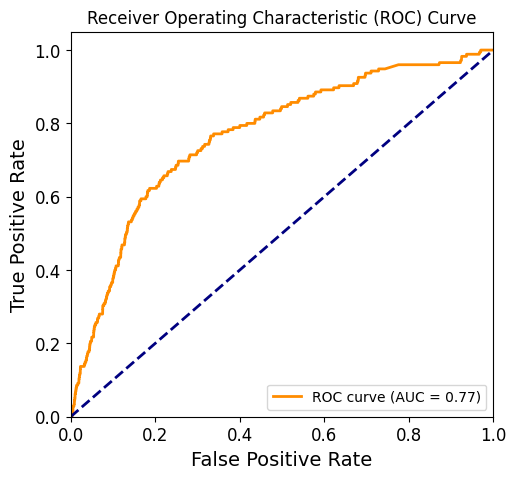

In [201]:
# ROC Curve
y_score=anomaly_scores
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# # PR curve
# plt.subplot(1, 2, 2)
# plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall (PR) Curve')
# plt.legend(loc="lower left")

# plt.tight_layout()
# plt.show()

# 4 Score Clusters

### 4.1 Anomaly Score

In [202]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

In [210]:
def generate_community_output(G, communities):   
    # Collect metrics for each community
    community_metrics = []

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)
        
        community_anomaly_scores = [anomaly_scores[node] for node in community]
        # avg_anomaly_score = sum(community_anomaly_scores) / len(community_anomaly_scores) if community_anomaly_scores else 0
    
        # Calculate metrics for anomaly scores within the community
        mean_score = np.mean(community_anomaly_scores)
        max_score = np.max(community_anomaly_scores)
        sum_score = np.sum(community_anomaly_scores)

        edge_weights = [data.get('edge_weight', 0) for u, v, data in subgraph.edges(data=True)]
        total_weight = sum(edge_weights)
        avg_edge_weight = total_weight / len(edge_weights) if edge_weights else 0

        node_list=[node for node, data in subgraph.nodes(data=True)]
        # Retrieve claim numbers:
        claim_list=[data['claim_number']for node, data in subgraph.nodes(data=True)]

        investigation_list = [data['investigation_flag'] for node, data in subgraph.nodes(data=True) if data['investigation_flag'] != 0]
        
        triage_list = [data['triage_flag'] for node, data in subgraph.nodes(data=True) if data['triage_flag'] != 0]
        
        allege_list = [data['alleged_flag'] for node, data in subgraph.nodes(data=True) if data['alleged_flag'] != 0]

        # # Clustering coefficient (average for nodes in the community)
        # avg_clustering = nx.average_clustering(subgraph)
        
        # # Conductance
        # conductance = compute_conductance(G, community)
        
        # # Density
        # density = nx.density(subgraph)
        
        # # Triangle count (sum of triangles in the community)
        # triangles = sum(nx.triangles(subgraph).values()) // 3  # Each triangle is counted thrice

        # Calculate percentage of nodes with y == 1
        total_nodes = len(community)
        y_count = sum(1 for node, data in subgraph.nodes(data=True) if data.get('y', 0) == 1)
        y_percentage = (y_count / total_nodes * 100) if total_nodes > 0 else 0
        
        # Add metrics to the list
        community_metrics.append({
            'Community': i,
            'Nodes': node_list,
            'Claim Numbers': claim_list,
            'Average edge weight':avg_edge_weight,
            'Investigated count': len(investigation_list),
            'mean_anomaly_score': mean_score,
            'max_anomaly_score': max_score,
            # 'sum_anomaly_score': sum_score,
            'Triaged count':len(triage_list),
            'Alleged count':len(allege_list),
            'Size': len(community),
            'investigation_rate': y_percentage # Optionally add community size
        })

    # Create a DataFrame
    df_metrics = pd.DataFrame(community_metrics)
    return df_metrics

In [ ]:
# community_scores = []
# for idx, row in df_filtered_metrics.iterrows():
#     community = row['Nodes']
#     community_anomaly_scores = [anomaly_scores[node] for node in community]
#     if not community_anomaly_scores:
#         continue
    
#     # Calculate metrics for anomaly scores within the community
#     mean_score = np.mean(community_anomaly_scores)
#     max_score = np.max(community_anomaly_scores)
#     sum_score = np.sum(community_anomaly_scores)
#     normalized_score = sum_score / len(community)
#             # Calculate the average degree for the community
#     subgraph = G.subgraph(community)
#     community_avg_degree = sum(dict(subgraph.degree()).values()) / len(subgraph.nodes()) if len(subgraph.nodes()) > 0 else 0
#     claim_list=[data['claim_number']for node, data in subgraph.nodes(data=True)]
#     investigation_list = [data['investigation_flag'] for node, data in subgraph.nodes(data=True) if data['investigation_flag'] != 0]
    
#     triage_list = [data['triage_flag'] for node, data in subgraph.nodes(data=True) if data['triage_flag'] != 0]
    
#     allege_list = [data['alleged_flag'] for node, data in subgraph.nodes(data=True) if data['alleged_flag'] != 0]
#     # Append the computed metrics for each community
#     community_scores.append({
#         'community_index': row['Community'],
#         'community_claims': claim_list,
#         'mean_score': mean_score,
#         'max_score': max_score,
#         'sum_score': sum_score,
#         # 'normalized_score': normalized_score,
#         'Investigated count': len(investigation_list),
#         'Triaged count':len(triage_list),
#         'Alleged count':len(allege_list),
#         'community_size': len(community),
#         'avg_connection':community_avg_degree
#     })

In [211]:
community_df = generate_community_output(G, filtered_communities)
community_df

,Community,Nodes,Claim Numbers,Average edge weight,Investigated count,mean_anomaly_score,max_anomaly_score,Triaged count,Alleged count,Size,investigation_rate
0,0,"[1153, 6792, 16142, 15762, 7706, 8731, 6173, 9...","[NWRND2200211, NWRTP1902020, NWRTP2202189, NWR...",1.384,0,136.143,396.208,3,0,29,0.000
1,1,"[7553, 14345, 5387, 2839, 414, 4265, 5806, 122...","[NWRTP1902845, NWRTP2200385, NWRTP1900509, NWR...",2.762,2,230.340,473.102,3,1,26,7.692
2,2,"[20704, 16449, 19650, 11587, 12707, 11491, 158...","[NWRTP2400782, NWRTP2202497, NWRTP2302919, NWR...",1.559,0,174.923,263.134,1,0,17,0.000
3,3,"[9760, 12377, 23586, 11171, 13124, 11974, 1626...","[NWRTP2001552, NWRTP2101233, NWRTP2500126, NWR...",1.083,0,126.069,256.519,3,0,17,0.000
4,4,"[15072, 15905, 21890, 21796, 18664, 7880, 1377...","[NWRTP2201115, NWRTP2201951, NWRTP2401977, NWR...",1.000,0,181.221,204.961,2,0,15,0.000
...,...,...,...,...,...,...,...,...,...,...,...
120,120,"[21953, 10476, 17109, 16926]","[NWRTP2402040, NWRTP2002269, NWRTP2300367, NWR...",2.000,0,139.029,223.856,0,0,4,0.000
121,121,"[1384, 7795, 620, 9812]","[NWRND2300160, NWRTP1903104, NWRND2000133, NWR...",1.167,0,125.762,213.494,1,0,4,0.000
122,122,"[9112, 12027, 21972, 17789]","[NWRTP2000899, NWRTP2100882, NWRTP2402059, NWR...",1.000,0,207.820,320.228,0,0,4,0.000
123,123,"[22338, 14139, 21964, 17541]","[NWRTP2402428, NWRTP2200178, NWRTP2402051, NWR...",3.000,0,298.077,530.379,2,0,4,0.000


In [235]:
# Create rank columns (lower rank = higher value)
community_df['rank_by_mean_anomaly'] = community_df['mean_anomaly_score'].rank(method='dense', ascending=False).astype(int)
community_df['rank_by_edge_weight'] = community_df['Average edge weight'].rank(method='dense', ascending=False).astype(int)

# Calculate the absolute difference between the two rankings
community_df['rank_diff'] = (community_df['rank_by_mean_anomaly'] - community_df['rank_by_edge_weight']).abs()

# Sort by rank_diff to see where the rankings differ most
rank_diff_df = community_df.sort_values(by='rank_diff', ascending=True).reset_index(drop=True)
rank_diff_df

,Community,Nodes,Claim Numbers,Average edge weight,Investigated count,mean_anomaly_score,max_anomaly_score,Triaged count,Alleged count,Size,investigation_rate,rank_by_mean_anomaly,rank_by_edge_weight,rank_diff
0,22,"[17697, 7874, 9545, 13481, 16937, 6224, 19956,...","[NWRTP2300960, NWRTP1903186, NWRTP2001334, NWR...",1.056,0,137.325,375.256,0,0,9,0.000,71,71,0
1,30,"[11200, 11394, 11877, 11271, 12297, 7379, 1093...","[NWRTP2100051, NWRTP2100245, NWRTP2100731, NWR...",2.714,0,197.623,556.382,0,0,8,0.000,34,33,1
2,17,"[7074, 8633, 6828, 5625, 6096, 7216, 13753, 13...","[NWRTP1902330, NWRTP2000411, NWRTP1902060, NWR...",1.978,0,179.663,525.372,0,0,10,0.000,44,45,1
3,41,"[21504, 13025, 24641, 20367, 12879, 21754]","[NWRTP2401589, NWRTP2101883, NWRTP2501182, NWR...",1.400,0,159.472,208.305,0,0,6,0.000,55,53,2
4,27,"[7394, 10979, 583, 10280, 11559, 1599, 16952, ...","[NWRTP1902672, NWRTP2002774, NWRND2000096, NWR...",7.690,3,274.737,416.020,4,1,9,33.333,7,9,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,44,"[15424, 6702, 6703, 6707, 23572, 9466]","[NWRTP2201467, NWRTP1901926, NWRTP1901927, NWR...",16.667,0,6.663,14.552,0,0,6,0.000,111,3,108
121,57,"[11493, 7337, 7306, 7320, 7324]","[NWRTP2100347, NWRTP1902610, NWRTP1902577, NWR...",16.600,0,2.775,2.910,0,0,5,0.000,112,4,108
122,63,"[13510, 16358, 13353, 6713, 6716]","[NWRTP2102369, NWRTP2202405, NWRTP2102211, NWR...",12.800,0,2.734,2.877,0,0,5,0.000,117,6,111
123,106,"[21834, 22567, 21102, 22775]","[NWRTP2401921, NWRTP2402659, NWRTP2401185, NWR...",6.333,0,2.595,2.963,0,0,4,0.000,125,14,111


In [236]:
comparison_df= rank_diff_df[['Community', 'Claim Numbers',
                             'Average edge weight', 'mean_anomaly_score', 'rank_by_mean_anomaly',
                             'rank_by_edge_weight', 'rank_diff', 'investigation_rate', 'Investigated count','Triaged count','Alleged count', 'Size']].copy()
comparison_df.to_csv('community_comparison.csv', index=False)      

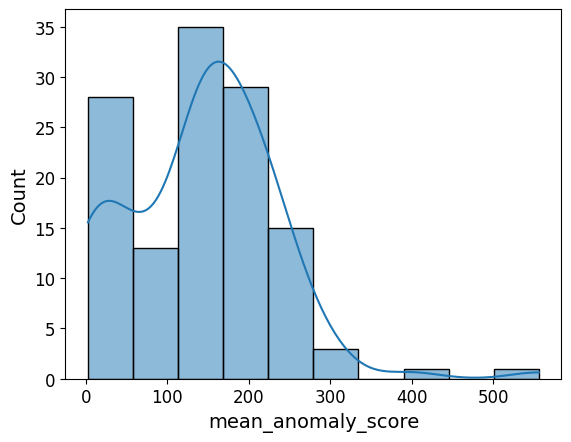

In [206]:
sns.histplot(community_df['mean_anomaly_score'], kde=True, bins=10) 
# plt.xlim(0,400) 
plt.show()

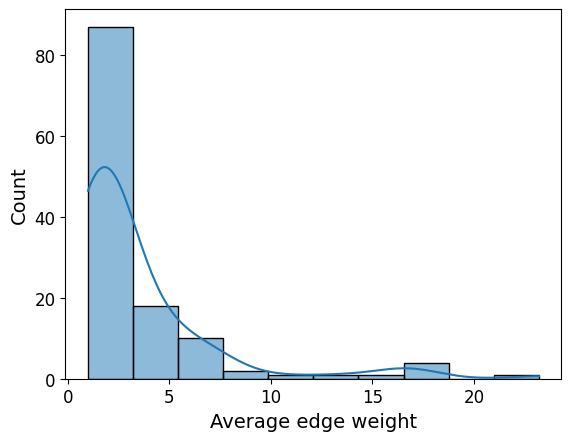

In [214]:
sns.histplot(community_df['Average edge weight'], kde=True, bins=10) 
# plt.xlim(0,500) 
plt.show()

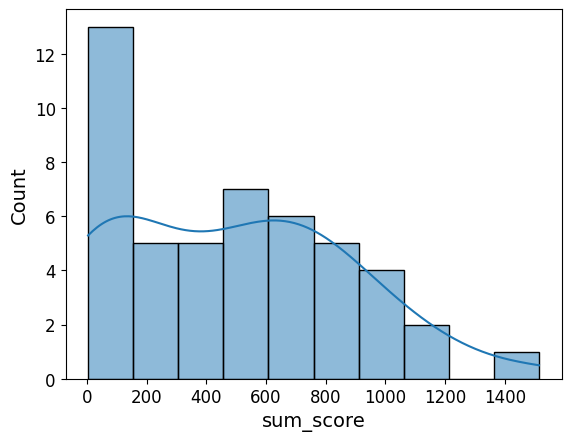

In [ ]:
sns.histplot(community_scores_df['sum_score'], kde=True, bins=10) 
plt.show()

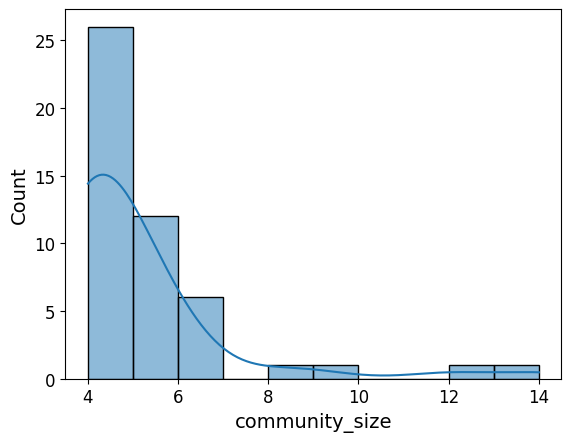

In [ ]:
sns.histplot(community_scores_df['community_size'], kde=True, bins=10) 
plt.show()

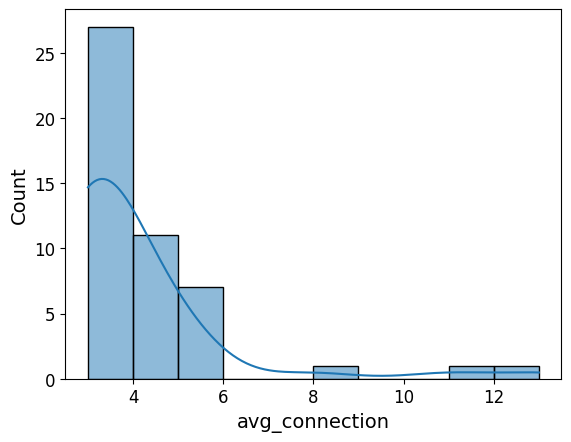

In [ ]:
sns.histplot(community_scores_df['avg_connection'], kde=True, bins=10) 
plt.show()

In [ ]:
community_scores_df['rank_mean'] = community_scores_df['mean_score'].rank(ascending=False, method='min')
community_scores_df['rank_max'] = community_scores_df['max_score'].rank(ascending=False, method='min')
community_scores_df['rank_sum'] = community_scores_df['sum_score'].rank(ascending=False, method='min')

# Calculate final rank using majority voting
# Majority voting can be simulated by summing ranks and then ranking communities again
community_scores_df['final_rank'] = (
    community_scores_df[['rank_mean', 'rank_max', 'rank_sum']].mean(axis=1)
).rank(ascending=True, method='min')

community_scores_df = community_scores_df.drop(columns=['rank_mean', 'rank_max', 'rank_sum']).sort_values(by='final_rank')
community_scores_df.head(10)

,community_index,community_claims,mean_score,max_score,sum_score,Investigated count,Triaged count,Alleged count,community_size,avg_connection,final_rank
22,1505,"[NWRTP1900948, NWRTP2002131, NWRTP1901785, NWR...",238.868,452.897,1194.342,0,0,0,5,3.600,1.000
36,2243,"[NWRTP1901678, NWRTP2302507, NWRTP2401402, NWR...",168.306,466.826,1514.754,0,2,0,9,8.000,2.000
13,1086,"[NWRTP1901325, NWRTP2101827, NWRTP2202377, NWR...",199.156,379.180,1194.935,0,0,0,6,5.000,3.000
42,2435,"[NWRTP2401670, NWRTP2302615, NWRTP2500398, NWR...",228.277,451.580,913.107,0,1,0,4,3.000,4.000
9,959,"[NWRTP2300090, NWRTP1902920, NWRTP1901960, NWR...",207.905,305.913,831.620,0,0,0,4,3.000,5.000
27,1920,"[NWRTP2200087, NWRTP2200088, NWRTP2200089, NWR...",166.989,386.767,834.943,0,4,0,5,4.000,6.000
33,2112,"[NWRTP2202178, NWRTP1801518, NWRTP2302307, NWR...",186.513,359.918,746.051,0,1,0,4,3.000,7.000
11,993,"[NWRTP2100700, NWRTP2100225, NWRTP2202484, NWR...",162.216,459.744,811.078,0,0,0,5,4.000,7.000
19,1381,"[NWRTP2401272, NWRTP2302060, NWRTP2100675, NWR...",196.376,237.967,981.882,0,0,0,5,4.000,9.000
16,1188,"[NWRTP2500189, NWRTP2001645, NWRTP2302250, NWR...",182.266,335.483,729.065,0,0,0,4,3.000,10.000


In [ ]:
output_df = community_scores_df.reset_index().merge(
    merged_df,
    how='inner',
    left_on='community_index',
    right_on='community_index'
)
output_df.drop(columns=['node_indexes','claim_numbers'],inplace=True)
output_df.head(5)

,index,community_index,community_claims,mean_score,max_score,sum_score,Investigated count_x,Triaged count_x,Alleged count_x,community_size,...,rego_number_count,Investigated count_y,Triaged count_y,Alleged count_y,Clustering Coefficient,Conductance,Density,Triangle Count,Size,investigation_rate
0,22,1505,"[NWRTP1900948, NWRTP2002131, NWRTP1901785, NWR...",238.868,452.897,1194.342,0,0,0,5,...,0,0,0,0,0.900,0.471,0.900,7,5,0.000
1,36,2243,"[NWRTP1901678, NWRTP2302507, NWRTP2401402, NWR...",168.306,466.826,1514.754,0,2,0,9,...,0,0,2,0,1.000,0.471,1.000,84,9,0.000
2,13,1086,"[NWRTP1901325, NWRTP2101827, NWRTP2202377, NWR...",199.156,379.180,1194.935,0,0,0,6,...,0,0,0,0,1.000,0.062,1.000,20,6,0.000
3,42,2435,"[NWRTP2401670, NWRTP2302615, NWRTP2500398, NWR...",228.277,451.580,913.107,0,1,0,4,...,1,0,1,0,1.000,0.000,1.000,4,4,0.000
4,9,959,"[NWRTP2300090, NWRTP1902920, NWRTP1901960, NWR...",207.905,305.913,831.620,0,0,0,4,...,0,0,0,0,1.000,0.000,1.000,4,4,0.000


In [ ]:
save_data(output_df, conf.data_path, 'results', data_extension='csv')

Data saved successfully locally as CSV: C:\GitHub\CTP_syndicate_model\data\results.csv


In [ ]:
# # Step 1: Calculate Ranks Based on Scores

# # Rank based on 'mean_score'
# community_scores_df['mean_rank'] = community_scores_df['mean_score'].rank(method='min', ascending=False)

# # Rank based on 'max_score'
# community_scores_df['max_rank'] = community_scores_df['max_score'].rank(method='min', ascending=False)

# # Rank based on 'sum_score'
# community_scores_df['sum_rank'] = community_scores_df['sum_score'].rank(method='min', ascending=False)

# # Step 2: Aggregate Ranks Using Sum of Ranks

# # Calculate total rank by summing ranks across metrics
# community_scores_df['total_rank'] = (
#     community_scores_df['mean_rank'] +
#     community_scores_df['max_rank'] +
#     community_scores_df['sum_rank']
# )

# # Step 3: Select Top 30 Syndicates

# # Sort communities based on 'total_rank' in ascending order
# community_scores_df.sort_values('total_rank', ascending=True, inplace=True)

# # Extract top 30 communities
# top_30_communities_df = community_scores_df.head(30)

# # Get the indices of the top 30 communities
# top_30_indices = top_30_communities_df.index.tolist()

# # Extract the actual communities
# top_30_communities = [filtered_communities[idx] for idx in top_30_indices]

# # Step 4: Analyze Top 30 Communities

# for idx, community in zip(top_30_indices, top_30_communities):
#     row = top_30_communities_df.loc[idx]
#     print(f"Community Index: {idx}")
#     print(f"Nodes: {community}")
#     print(f"Mean Score: {row['mean_score']}")
#     print(f"Max Score: {row['max_score']}")
#     print(f"Sum Score: {row['sum_score']}")
#     print(f"Total Rank: {row['total_rank']}")
#     print(f"Community Size: {row['community_size']}")
#     print("---")

Community Index: 5
Nodes: [7683, 5444, 6309, 4263, 9800, 5865, 3466, 4842, 5836, 3628, 11374, 6127, 11121, 8819, 1428, 2261, 1687, 6713]
Mean Score: 231.05154418945312
Max Score: 1203.8094482421875
Sum Score: 4158.927734375
Total Rank: 5.0
Community Size: 18
---
Community Index: 4
Nodes: [8576, 5130, 6542, 1680, 9618, 4499, 3476, 1437, 6051, 7466, 8875, 9265, 5179, 9149, 10066, 2399, 9314, 3821, 6767, 2547]
Mean Score: 196.8646240234375
Max Score: 842.054931640625
Sum Score: 3937.29248046875
Total Rank: 10.0
Community Size: 20
---
Community Index: 8
Nodes: [10626, 9858, 7815, 1543, 4745, 1554, 5398, 11287, 2464, 10533, 810, 12334, 193, 7492, 2629, 3531, 7375, 980, 1117, 10602, 6250, 7020, 10734, 2419, 6261, 7804]
Mean Score: 198.81341552734375
Max Score: 371.0820007324219
Sum Score: 5169.14892578125
Total Rank: 10.0
Community Size: 26
---
Community Index: 13
Nodes: [9348, 11782, 2955, 10508, 11406, 10776, 11564, 12205, 308, 7609, 11963, 6460, 7740, 3524, 10830, 10845, 8825, 10874, 1125

In [ ]:
global_avg_degree = sum(dict(G.degree()).values()) / len(G.nodes())
global_avg_degree


19.21555521798572